In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost openpyxl textblob transformers torch -q


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\mp2pf\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
 # =============================================================================
# CELL 1: INSTALL & IMPORT LIBRARY
# =============================================================================

# Import library dasar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import re
import time
import os

# Import library Machine Learning
from sklearn.model_selection  import (train_test_split, StratifiedKFold,
                                       cross_val_score, cross_validate,
                                       cross_val_predict, learning_curve)
from sklearn.preprocessing    import StandardScaler, LabelEncoder
from sklearn.metrics          import (classification_report, roc_auc_score,
                                       confusion_matrix, accuracy_score, f1_score,
                                       roc_curve)
from sklearn.svm              import SVC
from sklearn.pipeline         import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble         import RandomForestClassifier
from sklearn.linear_model     import LogisticRegression
from sklearn.tree             import DecisionTreeClassifier
from xgboost                  import XGBClassifier

# Import untuk Excel Report
from openpyxl                        import Workbook
from openpyxl.styles                 import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils.dataframe        import dataframe_to_rows
from datetime                        import datetime

# Matikan warning
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("✅ Semua library berhasil di-import!")
print("=" * 60)
print(f"📊 Pandas  : {pd.__version__}")
print(f"🔢 NumPy   : {np.__version__}")
print(f"🤖 Sklearn : {__import__('sklearn').__version__}")
print("=" * 60)


✅ Semua library berhasil di-import!
📊 Pandas  : 2.2.3
🔢 NumPy   : 2.4.6
🤖 Sklearn : 1.9.0


In [3]:
# =============================================================================
# CELL 2: LOAD DATA
# =============================================================================

# Load data
df = pd.read_csv('../data/raw/churn_data.csv')

print(f"📊 Shape of dataset: {df.shape}")
print(f"📋 Columns: {df.columns.tolist()}")
print("\n🔍 Preview Data:")
df.head()

📊 Shape of dataset: (36992, 28)
📋 Columns: ['age', 'gender', 'security_no', 'region_category', 'joining_date', 'joined_through_referral', 'referral_id', 'preferred_offer_types', 'medium_of_operation', 'internet_option', 'last_visit_time', 'days_since_last_login', 'avg_session_duration', 'avg_transaction_value', 'avg_frequency_login_days', 'points_in_wallet', 'used_special_discount', 'offer_application_preference', 'past_complaint', 'complaint_status', 'feedback', 'churn', 'plan_tier', 'logins_90d', 'active_days_90d', 'api_calls_90d', 'session_minutes_90d', 'days_since_active']

🔍 Preview Data:


,age,gender,security_no,region_category,joining_date,joined_through_referral,referral_id,preferred_offer_types,medium_of_operation,internet_option,...,past_complaint,complaint_status,feedback,churn,plan_tier,logins_90d,active_days_90d,api_calls_90d,session_minutes_90d,days_since_active
0,18,F,XW0DQ7H,Village,17-08-2017,No,xxxxxxxx,Gift Vouchers/Coupons,?,Wi-Fi,...,No,Not Applicable,Products always in Stock,0,Enterprise,46,33,8793,1027.11,2
1,32,F,5K0N3X1,City,28-08-2017,?,CID21329,Gift Vouchers/Coupons,Desktop,Mobile_Data,...,Yes,Solved,Quality Customer Care,0,Enterprise,37,30,8605,862.65,1
2,44,F,1F2TCL3,Town,11-11-2016,Yes,CID12313,Gift Vouchers/Coupons,Desktop,Wi-Fi,...,Yes,Solved in Follow-up,Poor Website,1,Basic,17,17,267,411.37,16
3,37,M,VJGJ33N,City,29-10-2016,Yes,CID3793,Gift Vouchers/Coupons,Desktop,Mobile_Data,...,Yes,Unsolved,Poor Website,1,Basic,8,8,227,215.77,20
4,31,F,SVZXCWB,City,12-09-2017,No,xxxxxxxx,Credit/Debit Card Offers,Smartphone,Mobile_Data,...,Yes,Solved,Poor Website,1,Basic,13,11,294,231.94,2


In [4]:
# =============================================================================
# CELL 3: DATA CLEANING & PREPROCESSING
# =============================================================================

# 1. Simpan data asli untuk referensi di report nanti
df_original = df.copy()

# 2. Menangani nilai yang tidak wajar (string error)
df.replace({'?': np.nan, 'Unknown': np.nan, 'Error': np.nan}, inplace=True)

# =============================================================================
# 🔥 3. HANDLE OUTLIERS & INVALID VALUES (TAMBAHAN PENTING)
# =============================================================================

# Konversi kolom numerik (paksa string → angka, error jadi NaN)
cols_to_convert = [
    'days_since_last_login',
    'avg_session_duration',
    'avg_frequency_login_days',
    'points_in_wallet',
    'session_minutes_90d'
]

for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# --- days_since_last_login ---
df.loc[df['days_since_last_login'] < 0, 'days_since_last_login'] = np.nan

# --- avg_session_duration ---
df.loc[(df['avg_session_duration'] < 0) |
       (df['avg_session_duration'] > 10000), 'avg_session_duration'] = np.nan

# --- avg_frequency_login_days ---
df.loc[(df['avg_frequency_login_days'] < 0) |
       (df['avg_frequency_login_days'] > 365), 'avg_frequency_login_days'] = np.nan

# --- points_in_wallet ---
df.loc[(df['points_in_wallet'] < 0) |
       (df['points_in_wallet'] > 1_000_000), 'points_in_wallet'] = np.nan

# --- session_minutes_90d ---
df.loc[df['session_minutes_90d'] > 130000, 'session_minutes_90d'] = np.nan


# =============================================================================
# 4. Feature Selection (Hapus fitur yang tidak relevan)
# =============================================================================
cols_to_drop = ['security_no', 'referral_id', 'last_visit_time']
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# =============================================================================
# 5. Transformasi Tanggal
# =============================================================================
df['joining_date'] = pd.to_datetime(df['joining_date'], format='%d-%m-%Y', errors='coerce')
reference_date = pd.to_datetime('2018-01-01')
df['days_since_joined'] = (reference_date - df['joining_date']).dt.days
df.drop('joining_date', axis=1, inplace=True)

# =============================================================================
# 6. Handling Missing Values
# Catatan: Kolom 'feedback' (jika ada) TIDAK di-drop dari df_original
#          agar bisa digunakan oleh SVM Churn Prediction di cell berikutnya.
# =============================================================================
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    # Jangan isi NaN pada kolom feedback; biarkan SVM cell yang handle
    if col not in ['feedback', 'Feedback', 'comment', 'Comment', 'review', 'Review']:
        df[col] = df[col].fillna(df[col].mode()[0])

# =============================================================================
# 8. EXPORT HASIL PREPROCESSING
# =============================================================================

# Simpan dataset yang sudah dibersihkan
import os
os.makedirs('../data/processed', exist_ok=True)
df.to_csv('../data/processed/cleaned_churn_data.csv', index=False)

print("💾 Data berhasil disimpan:")
print("- cleaned_churn_data.csv")

# =============================================================================
# DONE
# =============================================================================
print("✅ Data Cleaning + Outlier Handling Selesai!")
print(f"📊 Total baris: {len(df)}")
print(f"📋 Total kolom: {len(df.columns)}")

💾 Data berhasil disimpan:
- cleaned_churn_data.csv
✅ Data Cleaning + Outlier Handling Selesai!
📊 Total baris: 36992
📋 Total kolom: 25


In [6]:
# =============================================================================
# CELL 6: ENCODING & SPLITTING DATA
# =============================================================================

# Simpan data untuk report sebelum encoding
df_for_report = df.copy()

# Ensure 'churn' column is numeric and handle NaNs if any
# Convert 'churn' to numeric, coercing errors to NaN
df['churn'] = pd.to_numeric(df['churn'], errors='coerce')

# Fill NaNs in 'churn' with the mode, but be careful if mode itself is NaN (i.e., all values are NaN)
if df['churn'].isnull().all():
    print("WARNING: The 'churn' column contains only NaN values after conversion. Setting all to 0.")
    df['churn'] = 0 # Default to 0 (Not Churn) if all are NaN
elif df['churn'].isnull().any():
    churn_mode = df['churn'].mode()[0]
    df['churn'] = df['churn'].fillna(churn_mode)
    print(f"INFO: Filled NaN values in 'churn' with mode: {int(churn_mode)}")

# 1. Encode kolom kategorikal
cat_cols = df.select_dtypes(include=['object']).columns
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# 2. Definisikan X dan y
X = df.drop('churn', axis=1)
y = df['churn']

# Simpan nama fitur
feature_names = X.columns.tolist()

# 3. Split data (70:30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Simpan index untuk report
test_indices = X_test.index.tolist()

# 4. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Data Encoding & Splitting Selesai!")
print(f"📊 Training set: {X_train_scaled.shape[0]} samples")
print(f"📊 Test set: {X_test_scaled.shape[0]} samples")
print(f"📋 Jumlah fitur: {X_train_scaled.shape[1]}")

✅ Data Encoding & Splitting Selesai!
📊 Training set: 25894 samples
📊 Test set: 11098 samples
📋 Jumlah fitur: 24


SVM CHURN PREDICTION (TEKS + FITUR NUMERIK)
  Kolom teks  : feedback
  Fitur numerik: 10 kolom
  Train : 25894 | Test : 11098
  Churn (1) : 20012 (54.1%)

  Training SVM (LinearSVC + Calibration)...
  Training selesai!
  Threshold optimal (F1): 0.4569

HASIL EVALUASI SVM
  Accuracy  : 0.8568  (85.68%)
  F1-Score  : 0.8556  (weighted)
  ROC-AUC   : 0.9476

              precision    recall  f1-score   support

 Tidak Churn       0.89      0.78      0.83      5094
       Churn       0.83      0.92      0.87      6004

    accuracy                           0.86     11098
   macro avg       0.86      0.85      0.85     11098
weighted avg       0.86      0.86      0.86     11098

  CV Accuracy (5-Fold): 0.8575 +/- 0.0016
  CV AUC     (5-Fold): 0.9469 +/- 0.0016

  Distribusi prediksi seluruh dataset:
    Tidak Churn : 14914 (40.3%)
    Churn       : 22078 (59.7%)


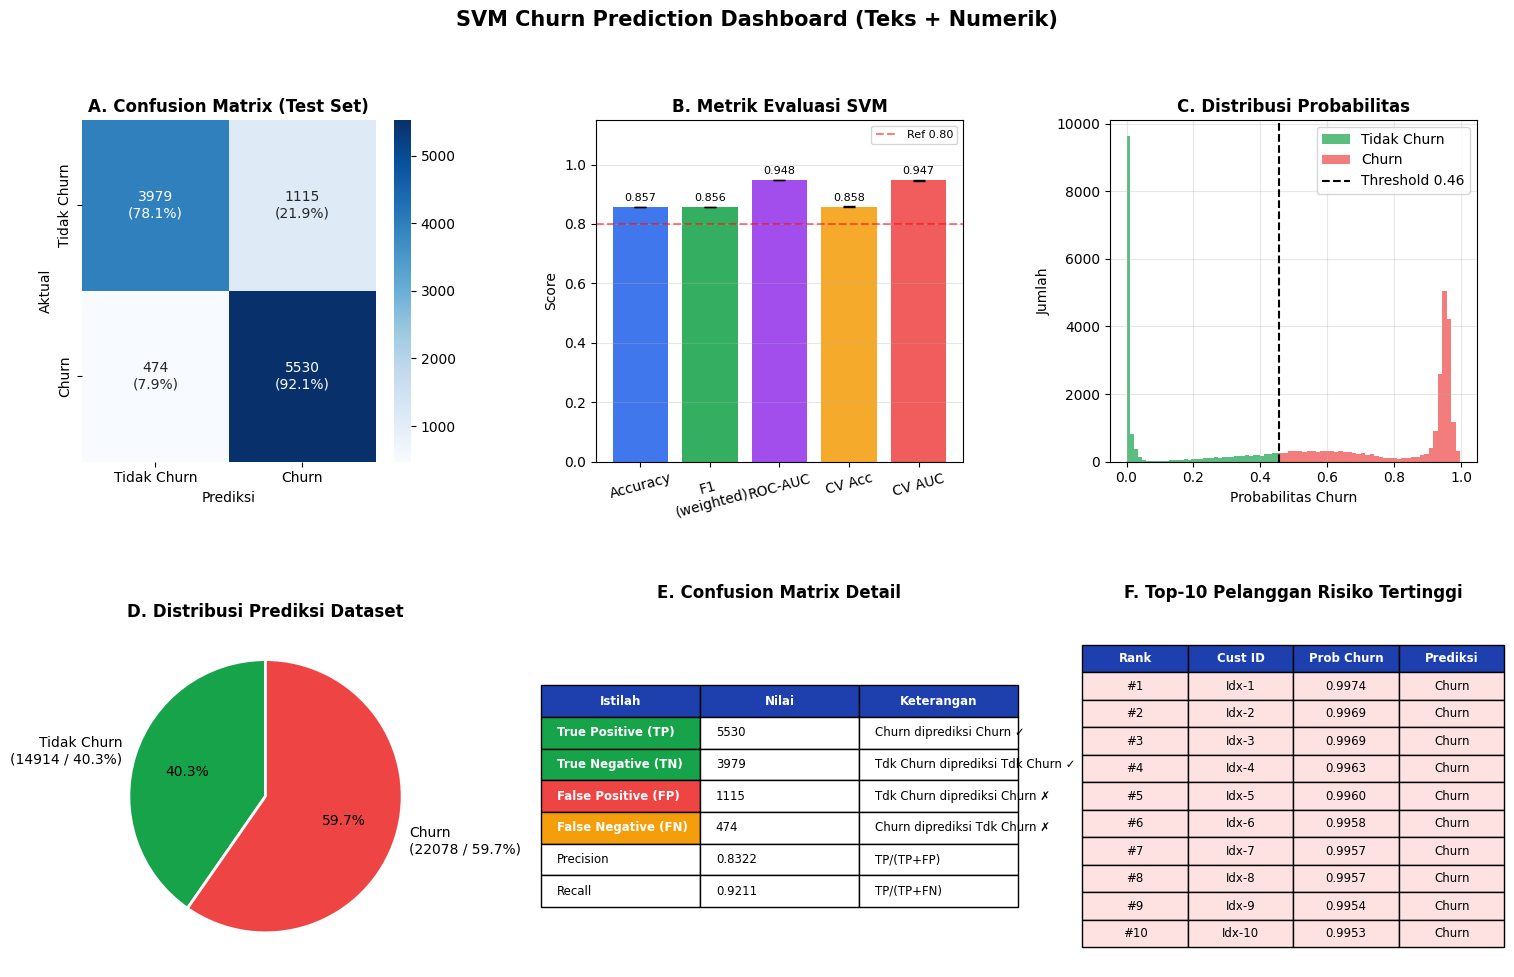


KESIMPULAN
  Model      : LinearSVC + Calibration | TF-IDF + Numerik
  Threshold  : 0.4569
  Accuracy   : 85.68%  |  ROC-AUC : 0.9476
  CV Acc     : 85.75% +/- 0.16%
  Churn      : 22078 pelanggan (59.7%)
  Tdk Churn  : 14914 pelanggan (40.3%)


In [5]:
# =============================================================================
# CELL 4: SVM CHURN PREDICTION (TEKS + FITUR NUMERIK)
# =============================================================================
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import scipy.sparse as sp

from sklearn.svm                     import LinearSVC
from sklearn.calibration             import CalibratedClassifierCV
from sklearn.pipeline                import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing           import StandardScaler
from sklearn.model_selection         import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics                 import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, precision_recall_curve
)

print('=' * 60)
print('SVM CHURN PREDICTION (TEKS + FITUR NUMERIK)')
print('=' * 60)

# ─── STEP 1: Siapkan label ────────────────────────────────────
churn_series = df_original['churn'].copy()
churn_series = pd.to_numeric(churn_series, errors='coerce').fillna(0)
y_svm = np.array(churn_series.astype(int).tolist(), dtype=np.int32)

# ─── STEP 2: Fitur TEKS (TF-IDF) ─────────────────────────────
fb_col = next((c for c in df_original.columns if c.lower() in
               ['feedback','comment','review','komentar','ulasan']), None)

def clean_text(t):
    t = str(t).lower()
    t = re.sub(r'[^a-zA-Z0-9\s]', ' ', t)
    return re.sub(r'\s+', ' ', t).strip()

if fb_col:
    print(f'  Kolom teks  : {fb_col}')
    X_text = np.array(df_original[fb_col].apply(clean_text).tolist(), dtype=str)
else:
    print('  Kolom teks tidak ditemukan, membuat teks sintetis...')
    X_text = np.array(
        df_original.drop(columns=['churn'], errors='ignore')
                   .astype(str).apply(lambda r: ' '.join(r), axis=1).tolist(),
        dtype=str
    )

# ─── STEP 3: Fitur NUMERIK ────────────────────────────────────
drop_cols = ['churn', fb_col] if fb_col else ['churn']
# Hanya ambil kolom numerik
num_df = df_original.drop(columns=drop_cols, errors='ignore')                     .select_dtypes(include=[np.number])
num_df = num_df.fillna(num_df.median())
scaler_svm = StandardScaler()
X_num = scaler_svm.fit_transform(num_df).astype(np.float32)
print(f'  Fitur numerik: {X_num.shape[1]} kolom')

# ─── STEP 4: Split ────────────────────────────────────────────
idx = np.arange(len(y_svm))
idx_tr, idx_te, y_tr, y_te = train_test_split(
    idx, y_svm, test_size=0.30, random_state=42, stratify=y_svm
)
print(f'  Train : {len(idx_tr)} | Test : {len(idx_te)}')
print(f'  Churn (1) : {y_svm.sum()} ({y_svm.mean()*100:.1f}%)')

# ─── STEP 5: TF-IDF fit ───────────────────────────────────────
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1,2),
                        sublinear_tf=True, min_df=2, strip_accents='unicode')
X_tfidf_tr = tfidf.fit_transform(X_text[idx_tr])
X_tfidf_te = tfidf.transform(X_text[idx_te])
X_tfidf_all = tfidf.transform(X_text)

# ─── STEP 6: Gabungkan teks + numerik ─────────────────────────
X_tr_comb  = sp.hstack([X_tfidf_tr,  sp.csr_matrix(X_num[idx_tr])],  format='csr')
X_te_comb  = sp.hstack([X_tfidf_te,  sp.csr_matrix(X_num[idx_te])],  format='csr')
X_all_comb = sp.hstack([X_tfidf_all, sp.csr_matrix(X_num)],           format='csr')

# ─── STEP 7: LinearSVC + Platt Calibration ────────────────────
# LinearSVC jauh lebih cepat untuk fitur sparse berdimensi tinggi
base_svc   = LinearSVC(C=0.5, max_iter=2000, class_weight='balanced', random_state=42)
svm_model  = CalibratedClassifierCV(base_svc, cv=3)
print('\n  Training SVM (LinearSVC + Calibration)...')
svm_model.fit(X_tr_comb, y_tr)
print('  Training selesai!')

# ─── STEP 8: Evaluasi ─────────────────────────────────────────
y_prob_te  = svm_model.predict_proba(X_te_comb)[:, 1]

# Cari threshold optimal via precision-recall
prec, rec, thresholds = precision_recall_curve(y_te, y_prob_te)
f1_scores  = 2 * prec * rec / np.where((prec + rec) == 0, 1, prec + rec)
best_thresh = thresholds[np.argmax(f1_scores[:-1])]
best_thresh = np.clip(best_thresh, 0.35, 0.65)   # batasi agar tidak ekstrem
print(f'  Threshold optimal (F1): {best_thresh:.4f}')

y_pred_svm = (y_prob_te >= best_thresh).astype(int)

acc_svm = accuracy_score(y_te, y_pred_svm)
f1_svm  = f1_score(y_te, y_pred_svm, average='weighted')
auc_svm = roc_auc_score(y_te, y_prob_te)
cm_svm  = confusion_matrix(y_te, y_pred_svm)

print('\n' + '=' * 60)
print('HASIL EVALUASI SVM')
print('=' * 60)
print(f'  Accuracy  : {acc_svm:.4f}  ({acc_svm*100:.2f}%)')
print(f'  F1-Score  : {f1_svm:.4f}  (weighted)')
print(f'  ROC-AUC   : {auc_svm:.4f}')
print()
print(classification_report(y_te, y_pred_svm, target_names=['Tidak Churn', 'Churn']))

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_acc = cross_val_score(svm_model, X_all_comb, y_svm, cv=skf, scoring='accuracy', n_jobs=-1)
cv_auc = cross_val_score(svm_model, X_all_comb, y_svm, cv=skf, scoring='roc_auc',  n_jobs=-1)
print(f'  CV Accuracy (5-Fold): {cv_acc.mean():.4f} +/- {cv_acc.std():.4f}')
print(f'  CV AUC     (5-Fold): {cv_auc.mean():.4f} +/- {cv_auc.std():.4f}')

# ─── STEP 9: Prediksi seluruh dataset ─────────────────────────
all_prob  = svm_model.predict_proba(X_all_comb)[:, 1]
all_pred  = (all_prob >= best_thresh).astype(int)

df_original['svm_churn_pred']  = all_pred
df_original['svm_churn_prob']  = np.round(all_prob, 4)
df_original['svm_churn_label'] = np.where(all_pred == 1, 'Churn', 'Tidak Churn')

dist = pd.Series(all_pred).value_counts()
print(f'\n  Distribusi prediksi seluruh dataset:')
print(f'    Tidak Churn : {dist.get(0,0)} ({dist.get(0,0)/len(all_pred)*100:.1f}%)')
print(f'    Churn       : {dist.get(1,0)} ({dist.get(1,0)/len(all_pred)*100:.1f}%)')

# ─── STEP 10: Dashboard Visualisasi ───────────────────────────
fig = plt.figure(figsize=(18, 11))
fig.suptitle('SVM Churn Prediction Dashboard (Teks + Numerik)', fontsize=15, fontweight='bold')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.48, wspace=0.40)

# A: Confusion Matrix
ax_a = fig.add_subplot(gs[0, 0])
tn, fp, fn, tp = cm_svm.ravel()
cm_pct = cm_svm.astype(float) / cm_svm.sum(axis=1, keepdims=True) * 100
annot  = np.array([[f'{tn}\n({cm_pct[0,0]:.1f}%)', f'{fp}\n({cm_pct[0,1]:.1f}%)'],
                    [f'{fn}\n({cm_pct[1,0]:.1f}%)', f'{tp}\n({cm_pct[1,1]:.1f}%)']])
sns.heatmap(cm_svm, annot=annot, fmt='', cmap='Blues', ax=ax_a,
            xticklabels=['Tidak Churn','Churn'],
            yticklabels=['Tidak Churn','Churn'])
ax_a.set_title('A. Confusion Matrix (Test Set)', fontweight='bold')
ax_a.set_xlabel('Prediksi'); ax_a.set_ylabel('Aktual')

# B: Metrik bar
ax_b = fig.add_subplot(gs[0, 1])
names = ['Accuracy','F1\n(weighted)','ROC-AUC','CV Acc','CV AUC']
vals  = [acc_svm, f1_svm, auc_svm, cv_acc.mean(), cv_auc.mean()]
stds  = [0, 0, 0, cv_acc.std(), cv_auc.std()]
clrs  = ['#2563EB','#16A34A','#9333EA','#F59E0B','#EF4444']
bars  = ax_b.bar(names, vals, color=clrs, alpha=0.87)
ax_b.errorbar(range(5), vals, yerr=stds, fmt='none', color='black', capsize=4)
ax_b.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)
ax_b.set_ylim(0, 1.15)
ax_b.axhline(0.80, color='red', ls='--', alpha=0.5, label='Ref 0.80')
ax_b.set_title('B. Metrik Evaluasi SVM', fontweight='bold')
ax_b.set_ylabel('Score'); ax_b.legend(fontsize=8)
ax_b.grid(axis='y', alpha=0.3); ax_b.tick_params(axis='x', rotation=15)

# C: Distribusi probabilitas
ax_c = fig.add_subplot(gs[0, 2])
ax_c.hist(all_prob[all_pred==0], bins=40, alpha=0.7, color='#16A34A', label='Tidak Churn')
ax_c.hist(all_prob[all_pred==1], bins=40, alpha=0.7, color='#EF4444', label='Churn')
ax_c.axvline(best_thresh, color='black', ls='--', lw=1.5, label=f'Threshold {best_thresh:.2f}')
ax_c.set_title('C. Distribusi Probabilitas', fontweight='bold')
ax_c.set_xlabel('Probabilitas Churn'); ax_c.set_ylabel('Jumlah')
ax_c.legend(); ax_c.grid(alpha=0.3)

# D: Pie chart
ax_d = fig.add_subplot(gs[1, 0])
pv = [dist.get(0,0), dist.get(1,0)]
ax_d.pie(pv,
         labels=[f'Tidak Churn\n({pv[0]} / {pv[0]/sum(pv)*100:.1f}%)',
                 f'Churn\n({pv[1]} / {pv[1]/sum(pv)*100:.1f}%)'],
         colors=['#16A34A','#EF4444'], autopct='%1.1f%%', startangle=90,
         wedgeprops={'edgecolor':'white','linewidth':2})
ax_d.set_title('D. Distribusi Prediksi Dataset', fontweight='bold')

# E: Tabel CM breakdown
ax_e = fig.add_subplot(gs[1, 1])
ax_e.axis('off')
rows = [
    ['True Positive (TP)',  str(tp), 'Churn diprediksi Churn ✓',     '#16A34A'],
    ['True Negative (TN)',  str(tn), 'Tdk Churn diprediksi Tdk Churn ✓','#16A34A'],
    ['False Positive (FP)', str(fp), 'Tdk Churn diprediksi Churn ✗', '#EF4444'],
    ['False Negative (FN)', str(fn), 'Churn diprediksi Tdk Churn ✗', '#F59E0B'],
]
tbl_data = [[r[0],r[1],r[2]] for r in rows]
tbl_data.append(['Precision', f'{tp/(tp+fp):.4f}' if (tp+fp)>0 else 'N/A', 'TP/(TP+FP)'])
tbl_data.append(['Recall',    f'{tp/(tp+fn):.4f}' if (tp+fn)>0 else 'N/A', 'TP/(TP+FN)'])
tbl = ax_e.table(cellText=tbl_data, colLabels=['Istilah','Nilai','Keterangan'],
                 loc='center', cellLoc='left')
tbl.auto_set_font_size(False); tbl.set_fontsize(8.5); tbl.scale(1.3, 1.9)
for j in range(3):
    tbl[0,j].set_facecolor('#1E40AF')
    tbl[0,j].set_text_props(color='white', fontweight='bold')
for i, r in enumerate(rows, 1):
    tbl[i,0].set_facecolor(r[3])
    tbl[i,0].set_text_props(color='white', fontweight='bold')
ax_e.set_title('E. Confusion Matrix Detail', fontweight='bold', pad=20)

# F: Top-10 risiko tertinggi
ax_f = fig.add_subplot(gs[1, 2])
ax_f.axis('off')

# Cari kolom ID
id_col = next((c for c in df_original.columns if c.lower() in ['customer_id','customerid','id','cust_id','no']), None)
cols_to_get = ['svm_churn_prob', 'svm_churn_label']
if id_col: cols_to_get.append(id_col)

top10 = df_original[cols_to_get].nlargest(10,'svm_churn_prob').reset_index(drop=True)
top10.index += 1

td = []
for i, r in top10.iterrows():
    c_id = str(r[id_col]) if id_col else f"Idx-{i}"
    # Potong ID jika terlalu panjang agar muat di tabel
    if len(c_id) > 12: c_id = c_id[:9] + "..."
    td.append([f'#{i}', c_id, f'{r["svm_churn_prob"]:.4f}', r['svm_churn_label']])

tbl_f = ax_f.table(cellText=td, colLabels=['Rank', 'Cust ID', 'Prob Churn', 'Prediksi'],
                   loc='center', cellLoc='center')
tbl_f.auto_set_font_size(False); tbl_f.set_fontsize(8.5); tbl_f.scale(1.15, 1.65)

# Styling Header Tabel Top 10
for j in range(4):
    tbl_f[0,j].set_facecolor('#1E40AF')
    tbl_f[0,j].set_text_props(color='white', fontweight='bold')

# Styling Isi Tabel Top 10
for i in range(1, len(td)+1):
    c = '#FEE2E2' if td[i-1][3]=='Churn' else '#DCFCE7'
    for j in range(4): tbl_f[i,j].set_facecolor(c)

ax_f.set_title('F. Top-10 Pelanggan Risiko Tertinggi', fontweight='bold', pad=20)

plt.tight_layout()
import os
os.makedirs('../reports', exist_ok=True)
plt.savefig('../reports/svm_churn_dashboard.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n' + '=' * 60)
print('KESIMPULAN')
print('=' * 60)
print(f'  Model      : LinearSVC + Calibration | TF-IDF + Numerik')
print(f'  Threshold  : {best_thresh:.4f}')
print(f'  Accuracy   : {acc_svm*100:.2f}%  |  ROC-AUC : {auc_svm:.4f}')
print(f'  CV Acc     : {cv_acc.mean()*100:.2f}% +/- {cv_acc.std()*100:.2f}%')
print(f'  Churn      : {dist.get(1,0)} pelanggan ({dist.get(1,0)/len(all_pred)*100:.1f}%)')
print(f'  Tdk Churn  : {dist.get(0,0)} pelanggan ({dist.get(0,0)/len(all_pred)*100:.1f}%)')
print('=' * 60)


In [7]:
# =============================================================================
# CELL 7: MODEL TRAINING (XGBoost)
# =============================================================================

# Inisialisasi model XGBoost
xgb_model = XGBClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=6,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

print("🔄 Training model XGBoost...")
xgb_model.fit(X_train_scaled, y_train)
print("✅ Model training selesai!")

# Prediksi
y_pred = xgb_model.predict(X_test_scaled)
y_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Prediksi untuk semua data (untuk report)
X_all_scaled = scaler.transform(X)
all_pred_proba = xgb_model.predict_proba(X_all_scaled)[:, 1]
all_pred = xgb_model.predict(X_all_scaled)

print(f"\n📊 Prediksi selesai untuk {len(all_pred)} pelanggan")

🔄 Training model XGBoost...
✅ Model training selesai!

📊 Prediksi selesai untuk 36992 pelanggan


METODE 1: 10-FOLD STRATIFIED CROSS-VALIDATION

[ACCURACY]
Train  : 0.9739 +/- 0.0011
Val CV : 0.9346 +/- 0.0057
Gap    : 0.0393 --> OK

[F1]
Train  : 0.9761 +/- 0.0010
Val CV : 0.9401 +/- 0.0050
Gap    : 0.0360 --> OK

[ROC_AUC]
Train  : 0.9962 +/- 0.0002
Val CV : 0.9765 +/- 0.0040
Gap    : 0.0197 --> OK

METODE 2: LEARNING CURVE
Gap AUC di 100% data training: 0.0196 --> OK


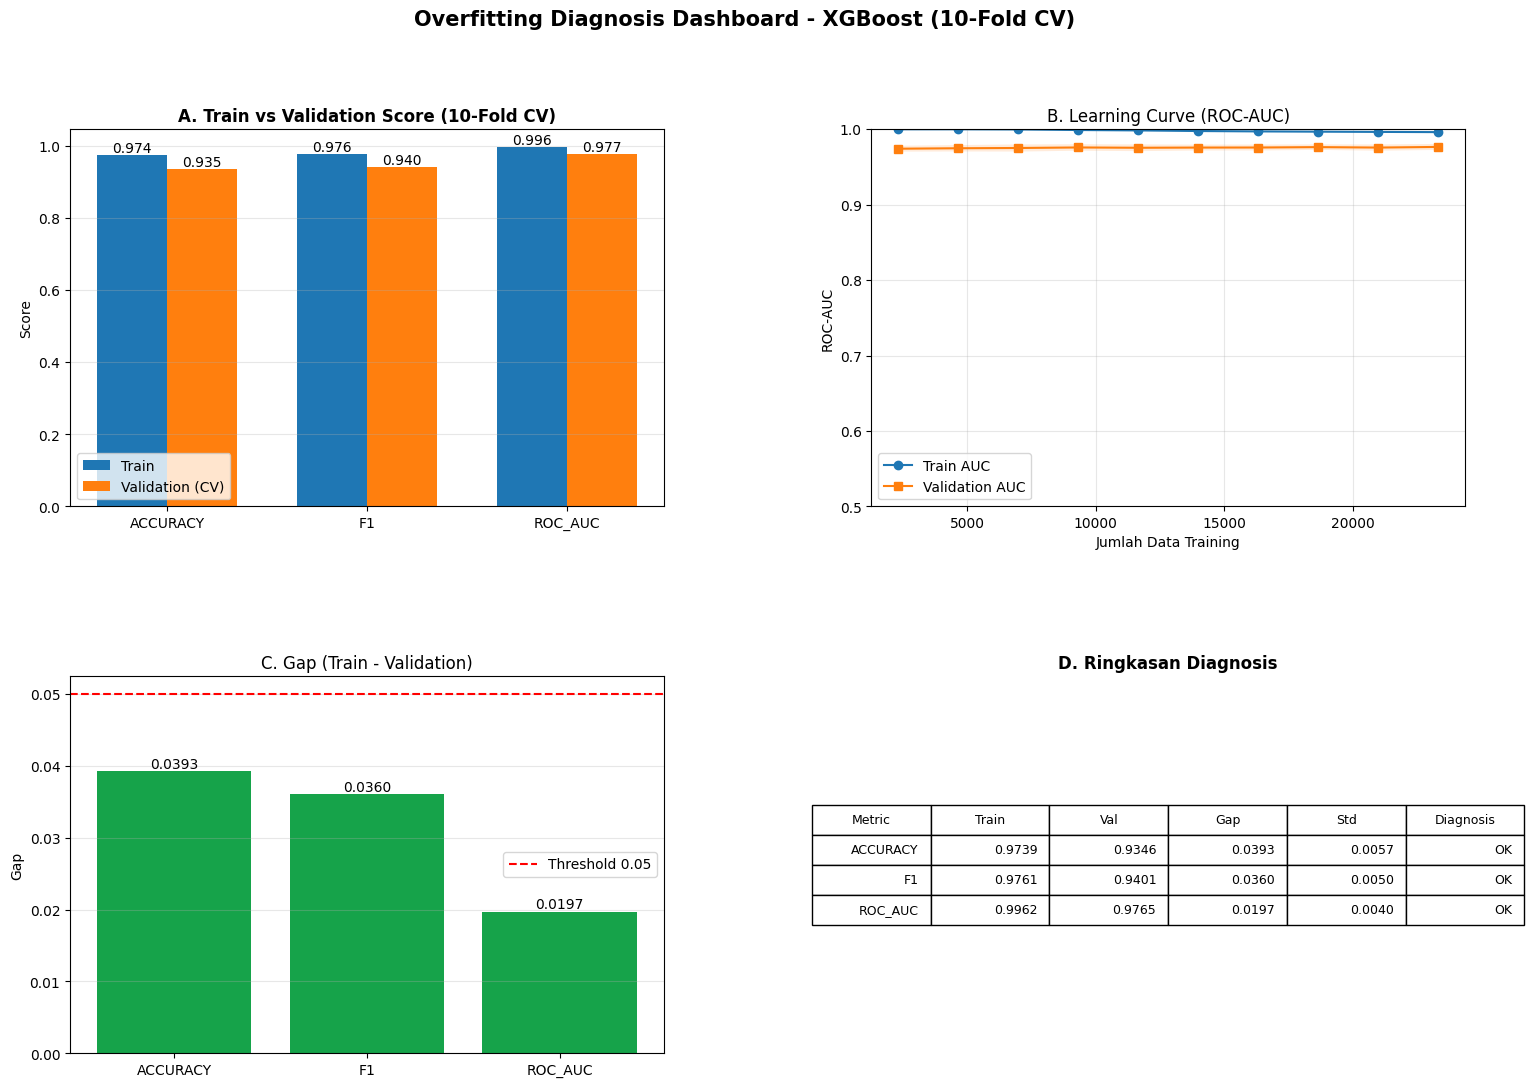


KESIMPULAN AKHIR
OK: Model TIDAK overfitting
Semua gap train-validation < 5%
Model mampu melakukan generalisasi dengan baik


In [30]:
# =============================================================================
# CELL 7B: CEK OVERFITTING MODEL XGBOOST (10-FOLD CV)
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import StratifiedKFold, cross_validate, learning_curve
from xgboost import XGBClassifier

# =============================================================================
# CONFIG
# =============================================================================
THRESHOLD = 0.05
CV_FOLDS = 10

# =============================================================================
# METODE 1: 10-FOLD STRATIFIED CROSS VALIDATION
# =============================================================================
print("=" * 60)
print(f"METODE 1: {CV_FOLDS}-FOLD STRATIFIED CROSS-VALIDATION")
print("=" * 60)

cv_model = XGBClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=6,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

skf = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=42
)

cv_results = cross_validate(
    cv_model,
    X_train_scaled,
    y_train,
    cv=skf,
    scoring=["accuracy", "f1", "roc_auc"],
    return_train_score=True,
    n_jobs=-1
)

cv_summary = {}

for metric in ["accuracy", "f1", "roc_auc"]:

    tr = cv_results[f"train_{metric}"]
    te = cv_results[f"test_{metric}"]

    gap = tr.mean() - te.mean()

    if gap > THRESHOLD:
        status = "WARNING: OVERFITTING"
    elif te.std() > 0.03:
        status = "WARNING: TIDAK STABIL"
    else:
        status = "OK"

    cv_summary[metric] = {
        "train": tr.mean(),
        "val": te.mean(),
        "gap": gap,
        "std": te.std()
    }

    print(f"\n[{metric.upper()}]")
    print(f"Train  : {tr.mean():.4f} +/- {tr.std():.4f}")
    print(f"Val CV : {te.mean():.4f} +/- {te.std():.4f}")
    print(f"Gap    : {gap:.4f} --> {status}")

# =============================================================================
# METODE 2: LEARNING CURVE
# =============================================================================
print()
print("=" * 60)
print("METODE 2: LEARNING CURVE")
print("=" * 60)

lc_model = XGBClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=6,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

train_sizes_abs, train_scores_lc, val_scores_lc = learning_curve(
    lc_model,
    X_train_scaled,
    y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=StratifiedKFold(
        n_splits=CV_FOLDS,
        shuffle=True,
        random_state=42
    ),
    scoring="roc_auc",
    n_jobs=-1
)

train_mean_lc = train_scores_lc.mean(axis=1)
train_std_lc = train_scores_lc.std(axis=1)

val_mean_lc = val_scores_lc.mean(axis=1)
val_std_lc = val_scores_lc.std(axis=1)

final_gap_lc = train_mean_lc[-1] - val_mean_lc[-1]

print(
    f"Gap AUC di 100% data training: "
    f"{final_gap_lc:.4f} --> "
    f"{'WARNING: OVERFITTING' if final_gap_lc > THRESHOLD else 'OK'}"
)

# =============================================================================
# DASHBOARD
# =============================================================================
fig = plt.figure(figsize=(18, 12))

fig.suptitle(
    f"Overfitting Diagnosis Dashboard - XGBoost ({CV_FOLDS}-Fold CV)",
    fontsize=15,
    fontweight="bold"
)

gs = gridspec.GridSpec(
    2,
    2,
    figure=fig,
    hspace=0.45,
    wspace=0.35
)

# =============================================================================
# PANEL A - TRAIN VS VALIDATION
# =============================================================================
ax_a = fig.add_subplot(gs[0, 0])

metrics_list = list(cv_summary.keys())

train_vals = [cv_summary[m]["train"] for m in metrics_list]
val_vals = [cv_summary[m]["val"] for m in metrics_list]

x = np.arange(len(metrics_list))

bars_t = ax_a.bar(
    x - 0.175,
    train_vals,
    0.35,
    label="Train",
)

bars_v = ax_a.bar(
    x + 0.175,
    val_vals,
    0.35,
    label="Validation (CV)",
)

ax_a.bar_label(bars_t, fmt="%.3f")
ax_a.bar_label(bars_v, fmt="%.3f")

ax_a.set_xticks(x)
ax_a.set_xticklabels([m.upper() for m in metrics_list])

ax_a.set_title(
    f"A. Train vs Validation Score ({CV_FOLDS}-Fold CV)",
    fontweight="bold"
)

ax_a.set_ylabel("Score")
ax_a.legend()
ax_a.grid(axis="y", alpha=0.3)

# =============================================================================
# PANEL B - LEARNING CURVE
# =============================================================================
ax_b = fig.add_subplot(gs[0, 1])

ax_b.plot(
    train_sizes_abs,
    train_mean_lc,
    "o-",
    label="Train AUC"
)

ax_b.fill_between(
    train_sizes_abs,
    train_mean_lc - train_std_lc,
    train_mean_lc + train_std_lc,
    alpha=0.15
)

ax_b.plot(
    train_sizes_abs,
    val_mean_lc,
    "s-",
    label="Validation AUC"
)

ax_b.fill_between(
    train_sizes_abs,
    val_mean_lc - val_std_lc,
    val_mean_lc + val_std_lc,
    alpha=0.15
)

ax_b.set_title("B. Learning Curve (ROC-AUC)")
ax_b.set_xlabel("Jumlah Data Training")
ax_b.set_ylabel("ROC-AUC")
ax_b.set_ylim(0.5, 1.0)
ax_b.legend()
ax_b.grid(alpha=0.3)

# =============================================================================
# PANEL C - GAP ANALYSIS
# =============================================================================
ax_c = fig.add_subplot(gs[1, 0])

gaps = [cv_summary[m]["gap"] for m in metrics_list]

colors = [
    "#EF4444" if g > THRESHOLD else "#16A34A"
    for g in gaps
]

bars = ax_c.bar(
    [m.upper() for m in metrics_list],
    gaps,
    color=colors
)

ax_c.bar_label(bars, fmt="%.4f")

ax_c.axhline(
    THRESHOLD,
    color="red",
    linestyle="--",
    label=f"Threshold {THRESHOLD}"
)

ax_c.set_title("C. Gap (Train - Validation)")
ax_c.set_ylabel("Gap")
ax_c.legend()
ax_c.grid(axis="y", alpha=0.3)

# =============================================================================
# PANEL D - SUMMARY TABLE
# =============================================================================
ax_d = fig.add_subplot(gs[1, 1])
ax_d.axis("off")

rows = []

for m in metrics_list:

    s = cv_summary[m]

    if s["gap"] > THRESHOLD:
        diag = "OVERFITTING"
    elif s["std"] > 0.03:
        diag = "TIDAK STABIL"
    else:
        diag = "OK"

    rows.append([
        m.upper(),
        f"{s['train']:.4f}",
        f"{s['val']:.4f}",
        f"{s['gap']:.4f}",
        f"{s['std']:.4f}",
        diag
    ])

table = ax_d.table(
    cellText=rows,
    colLabels=[
        "Metric",
        "Train",
        "Val",
        "Gap",
        "Std",
        "Diagnosis"
    ],
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.8)

ax_d.set_title(
    "D. Ringkasan Diagnosis",
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# =============================================================================
# VERDICT AKHIR
# =============================================================================
print()
print("=" * 60)
print("KESIMPULAN AKHIR")
print("=" * 60)

all_ok = (
    all(
        cv_summary[m]["gap"] <= THRESHOLD
        and cv_summary[m]["std"] <= 0.03
        for m in metrics_list
    )
    and final_gap_lc <= THRESHOLD
)

if all_ok:
    print("OK: Model TIDAK overfitting")
    print("Semua gap train-validation < 5%")
    print("Model mampu melakukan generalisasi dengan baik")
else:
    print("WARNING: Model kemungkinan OVERFITTING")
    print("Saran:")
    print("- Turunkan max_depth")
    print("- Naikkan min_child_weight")
    print("- Tambah regularisasi")
    print("- Kurangi learning_rate dan tambah n_estimators")

📊 CLASSIFICATION REPORT XGBoost 
              precision    recall  f1-score   support

   Not Churn       0.94      0.91      0.93      5094
       Churn       0.93      0.95      0.94      6004

    accuracy                           0.93     11098
   macro avg       0.93      0.93      0.93     11098
weighted avg       0.93      0.93      0.93     11098


🎯 ROC-AUC Score: 0.9760


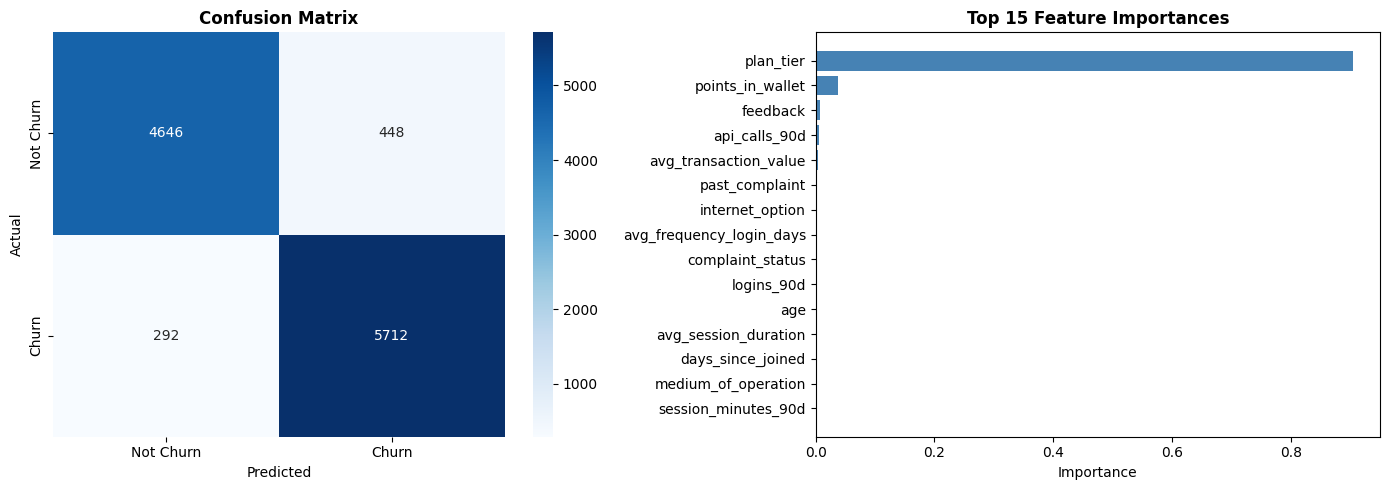

In [32]:
# =============================================================================
# CELL 10: EVALUASI MODEL XGBoost 
# =============================================================================

# 1. Classification Report
print("=" * 60)
print("📊 CLASSIFICATION REPORT XGBoost ")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Not Churn', 'Churn']))

# 2. ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"\n🎯 ROC-AUC Score: {roc_auc:.4f}")

# 3. Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Churn', 'Churn'],
            yticklabels=['Not Churn', 'Churn'])
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Feature Importance (Top 15)
importances = xgb_model.feature_importances_
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=True).tail(15)

axes[1].barh(fi_df['Feature'], fi_df['Importance'], color='steelblue')
axes[1].set_title('Top 15 Feature Importances', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

In [9]:
# =============================================================================
# CELL 8: TRAINING MODEL — LOGISTIC REGRESSION
# =============================================================================

from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer

print("🔄 Handling remaining NaNs for Logistic Regression...")
# Logistic Regression cannot handle NaNs. We use an imputer to fill any gaps.
imputer = SimpleImputer(strategy='constant', fill_value=0)
X_train_imputed = imputer.fit_transform(X_train_scaled)
X_test_imputed = imputer.transform(X_test_scaled)

print("🔄 Training Logistic Regression...")
lr_model = LogisticRegression(
    max_iter=1000,
    C=1.0,
    solver='lbfgs',
    class_weight='balanced',
    random_state=42
)

lr_model.fit(X_train_imputed, y_train)

# Prediksi
y_pred_lr       = lr_model.predict(X_test_imputed)
y_pred_proba_lr = lr_model.predict_proba(X_test_imputed)[:, 1]

print("✅ Logistic Regression selesai!")
print(f"   Training samples : {X_train_imputed.shape[0]}")
print(f"   Test samples     : {X_test_imputed.shape[0]}")

🔄 Handling remaining NaNs for Logistic Regression...
🔄 Training Logistic Regression...
✅ Logistic Regression selesai!
   Training samples : 25894
   Test samples     : 11098


In [10]:
# =============================================================================
# CELL 9: TRAINING MODEL — RANDOM FOREST
# =============================================================================

from sklearn.ensemble import RandomForestClassifier

print("🔄 Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf       = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("✅ Random Forest selesai!")
print(f"   Training samples : {X_train_scaled.shape[0]}")
print(f"   Test samples     : {X_test_scaled.shape[0]}")


🔄 Training Random Forest...
✅ Random Forest selesai!
   Training samples : 25894
   Test samples     : 11098


In [12]:
# =============================================================================
# CELL 11: EVALUASI MODEL — LOGISTIC REGRESSION
# =============================================================================

from sklearn.metrics import classification_report, roc_auc_score

print("=" * 60)
print("📊 CLASSIFICATION REPORT — LOGISTIC REGRESSION")
print("=" * 60)
print(classification_report(y_test, y_pred_lr, target_names=["Not Churn", "Churn"]))

roc_auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
print(f"🎯 ROC-AUC Score: {roc_auc_lr:.4f}")


📊 CLASSIFICATION REPORT — LOGISTIC REGRESSION
              precision    recall  f1-score   support

   Not Churn       0.81      0.91      0.86      5094
       Churn       0.91      0.82      0.86      6004

    accuracy                           0.86     11098
   macro avg       0.86      0.87      0.86     11098
weighted avg       0.87      0.86      0.86     11098

🎯 ROC-AUC Score: 0.9441


In [13]:
# =============================================================================
# CELL 12: EVALUASI MODEL — RANDOM FOREST
# =============================================================================

from sklearn.metrics import classification_report, roc_auc_score

print("=" * 60)
print("📊 CLASSIFICATION REPORT — RANDOM FOREST")
print("=" * 60)
print(classification_report(y_test, y_pred_rf, target_names=["Not Churn", "Churn"]))

roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
print(f"🎯 ROC-AUC Score: {roc_auc_rf:.4f}")


📊 CLASSIFICATION REPORT — RANDOM FOREST
              precision    recall  f1-score   support

   Not Churn       0.91      0.94      0.93      5094
       Churn       0.95      0.92      0.94      6004

    accuracy                           0.93     11098
   macro avg       0.93      0.93      0.93     11098
weighted avg       0.93      0.93      0.93     11098

🎯 ROC-AUC Score: 0.9745


🔄 Menghitung SHAP values untuk XGBoost...
✅ SHAP values dihitung! Shape: (11098, 24)

📊 Plot 1: SHAP Beeswarm Summary Plot


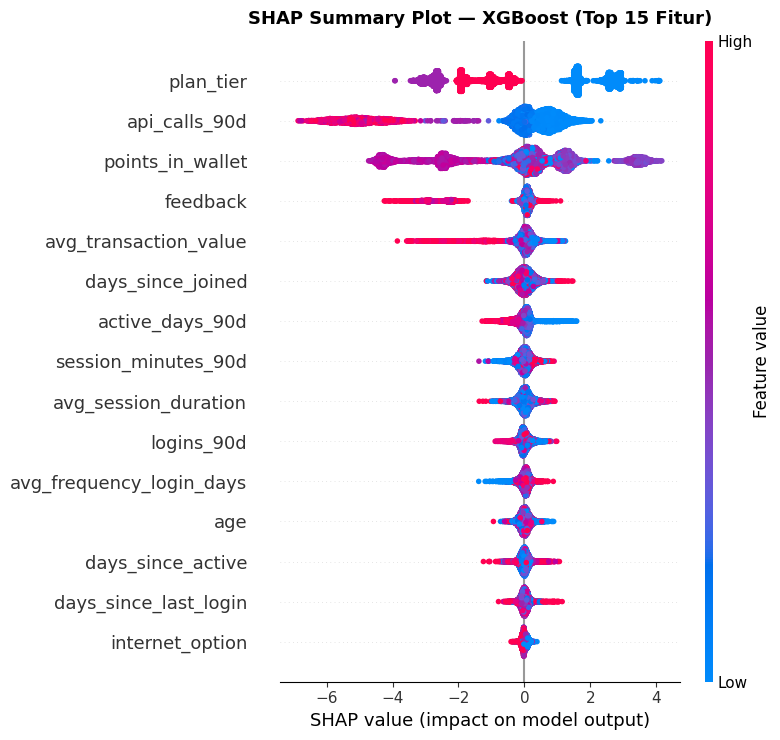


📊 Plot 2: SHAP Feature Importance (Mean |SHAP|)


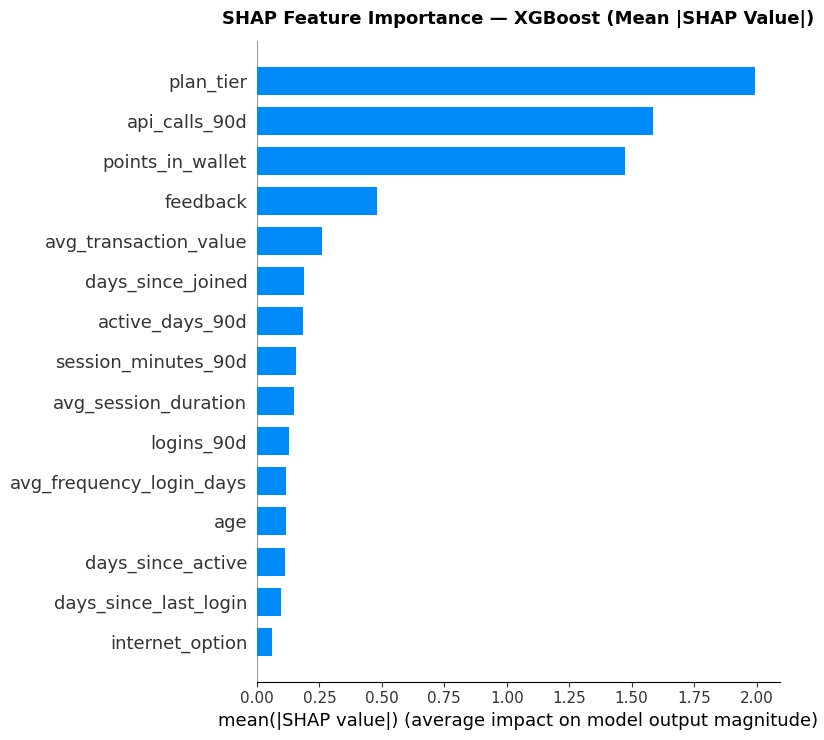


🔍 TOP 10 FITUR BERDASARKAN SHAP (XGBoost)
              Feature  Mean |SHAP|
            plan_tier     1.994111
        api_calls_90d     1.583673
     points_in_wallet     1.471847
             feedback     0.482250
avg_transaction_value     0.258444
    days_since_joined     0.187546
      active_days_90d     0.185551
  session_minutes_90d     0.154988
 avg_session_duration     0.148122
           logins_90d     0.128933

✅ SHAP analysis selesai!


In [31]:
# =============================================================================
# CELL 13: SHAP EXPLAINABILITY — XGBoost
# =============================================================================

import importlib, subprocess
if importlib.util.find_spec("shap") is None:
    print("📦 Installing shap...")
    subprocess.run(["pip", "install", "shap", "-q"], check=True)
    print("✅ shap installed!")

import shap
import pandas as pd
import matplotlib.pyplot as plt

print("🔄 Menghitung SHAP values untuk XGBoost...")
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_scaled)
X_test_df   = pd.DataFrame(X_test_scaled, columns=feature_names)
print(f"✅ SHAP values dihitung! Shape: {shap_values.shape}")

# ── Plot 1: Beeswarm Summary Plot ────────────────────────────────────────────
print("\n📊 Plot 1: SHAP Beeswarm Summary Plot")
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_df, plot_type="dot", max_display=15, show=False)
plt.title("SHAP Summary Plot — XGBoost (Top 15 Fitur)", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

# ── Plot 2: Bar Plot (Mean |SHAP|) ───────────────────────────────────────────
print("\n📊 Plot 2: SHAP Feature Importance (Mean |SHAP|)")
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_test_df, plot_type="bar", max_display=15, show=False)
plt.title("SHAP Feature Importance — XGBoost (Mean |SHAP Value|)", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

# ── Plot 3: Waterfall untuk pelanggan risiko tertinggi ───────────────────────
# print("\n📊 Plot 3: Waterfall — Pelanggan risiko churn tertinggi")
# high_risk_idx = y_pred_proba.argmax()
# shap_explanation = shap.Explanation(
#     values        = shap_values[high_risk_idx],
#     base_values   = explainer.expected_value,
#     data          = X_test_df.iloc[high_risk_idx].values,
#     feature_names = feature_names
# )
# plt.figure(figsize=(10, 6))
# shap.plots.waterfall(shap_explanation, max_display=12, show=False)
# plt.title(
#     f"SHAP Waterfall — Pelanggan Risiko Tertinggi (Churn Prob: {y_pred_proba[high_risk_idx]:.2%})",
#     fontsize=12, fontweight="bold"
# )
# plt.tight_layout()
# plt.show()

# ── Tabel Top Fitur ───────────────────────────────────────────────────────────
mean_shap = pd.DataFrame({
    "Feature"    : feature_names,
    "Mean |SHAP|": abs(shap_values).mean(axis=0)
}).sort_values("Mean |SHAP|", ascending=False).reset_index(drop=True)

print("\n" + "="*50)
print("🔍 TOP 10 FITUR BERDASARKAN SHAP (XGBoost)")
print("="*50)
print(mean_shap.head(10).to_string(index=False))
print("="*50)
print("\n✅ SHAP analysis selesai!")


In [15]:
# =============================================================================
# CELL 16: PREVIEW REPORT - SVM CHURN PREDICTION
# =============================================================================

import pandas as pd
import numpy as np

# ─── Bangun report_df dari df_original + hasil SVM ───────────────────────────
# Cari kolom ID pelanggan jika ada
id_col   = next((c for c in df_original.columns if c.lower() in
                 ['customer_id','customerid','id','cust_id','no']), None)
name_col = next((c for c in df_original.columns if c.lower() in
                 ['name','nama','customer_name','custname']), None)
fb_col   = next((c for c in df_original.columns if c.lower() in
                 ['feedback','comment','review','komentar','ulasan']), None)

def get_risk_level(prob):
    if prob >= 0.80: return "🔴 Sangat Tinggi"
    if prob >= 0.60: return "🟠 Tinggi"
    if prob >= 0.40: return "🟡 Sedang"
    return "🟢 Rendah"

def get_solusi(prob, feedback_text=""):
    if prob >= 0.80:
        return "Hubungi pelanggan segera, tawarkan retensi khusus / diskon loyalitas."
    if prob >= 0.60:
        return "Kirim survei kepuasan + follow-up personal dalam 3 hari."
    if prob >= 0.40:
        return "Monitor aktivitas, kirim notifikasi promo atau program poin."
    return "Pertahankan pengalaman positif, pertimbangkan program referral."

def get_masalah(prob):
    if prob >= 0.80: return "Ketidakpuasan tinggi – risiko churn sangat kritis."
    if prob >= 0.60: return "Indikasi kuat pelanggan tidak puas dengan layanan."
    if prob >= 0.40: return "Sinyal peringatan dini – perlu perhatian lebih lanjut."
    return "Tidak terdeteksi masalah signifikan."

report_df = df_original.copy()

# Pastikan kolom SVM tersedia (jalankan Cell 4 jika belum)
if 'svm_churn_prob' not in report_df.columns:
    raise RuntimeError("Kolom 'svm_churn_prob' tidak ditemukan. Pastikan Cell 4 (SVM) sudah dijalankan.")

# Normalisasi nama kolom
report_df['Customer_ID']              = report_df[id_col].astype(str)   if id_col   else report_df.index.astype(str)
report_df['Nama']                     = report_df[name_col].astype(str) if name_col else 'N/A'
report_df['Feedback_Original']        = report_df[fb_col].astype(str)   if fb_col   else '-'
report_df['Churn_Probability']        = report_df['svm_churn_prob']
report_df['Churn_Probability_Percent']= (report_df['svm_churn_prob'] * 100).round(2)
report_df['Prediksi']                 = report_df['svm_churn_label']
report_df['Risk_Level']               = report_df['svm_churn_prob'].apply(get_risk_level)
report_df['Masalah']                  = report_df['svm_churn_prob'].apply(get_masalah)
report_df['Solusi']                   = report_df['svm_churn_prob'].apply(get_solusi)
report_df['Kesimpulan']               = report_df.apply(
    lambda r: f"Pelanggan diprediksi {'CHURN' if r['svm_churn_pred']==1 else 'TIDAK CHURN'} "
              f"dengan probabilitas {r['Churn_Probability_Percent']}% berdasarkan analisis feedback via SVM.",
    axis=1
)

# ─── Tampilkan Preview ────────────────────────────────────────────────────────
print("=" * 80)
print("📋 PREVIEW REPORT - 5 PELANGGAN DENGAN RISIKO CHURN TERTINGGI")
print("=" * 80)

high_risk = report_df.nlargest(5, 'Churn_Probability')

for idx, row in high_risk.iterrows():
    print(f"\n{'─' * 70}")
    cust_label = f"{row['Customer_ID']}" + (f" | {row['Nama']}" if row['Nama'] != 'N/A' else '')
    print(f"👤 Pelanggan #{idx}  —  {cust_label}")
    print(f"{'─' * 70}")
    print(f"📊 Churn Probability : {row['Churn_Probability_Percent']}%")
    print(f"🏷️  Prediksi          : {row['Prediksi']}")
    print(f"⚠️   Risk Level        : {row['Risk_Level']}")
    fb = str(row['Feedback_Original'])
    print(f"💬 Feedback          : {fb[:100]}..." if len(fb) > 100 else f"💬 Feedback          : {fb}")
    print(f"\n❌ MASALAH  : {row['Masalah']}")
    print(f"✅ SOLUSI   : {row['Solusi']}")
    print(f"\n📝 KESIMPULAN: {row['Kesimpulan']}")

print(f"\n{'=' * 80}")
print(f"Total pelanggan dianalisis  : {len(report_df)}")
churn_count    = int(report_df['svm_churn_pred'].sum())
no_churn_count = len(report_df) - churn_count
print(f"Prediksi Churn              : {churn_count} pelanggan ({churn_count/len(report_df)*100:.1f}%)")
print(f"Prediksi Tidak Churn        : {no_churn_count} pelanggan ({no_churn_count/len(report_df)*100:.1f}%)")
print(f"{'=' * 80}")


📋 PREVIEW REPORT - 5 PELANGGAN DENGAN RISIKO CHURN TERTINGGI

──────────────────────────────────────────────────────────────────────
👤 Pelanggan #67  —  67
──────────────────────────────────────────────────────────────────────
📊 Churn Probability : 99.74%
🏷️  Prediksi          : Churn
⚠️   Risk Level        : 🔴 Sangat Tinggi
💬 Feedback          : Too many ads

❌ MASALAH  : Ketidakpuasan tinggi – risiko churn sangat kritis.
✅ SOLUSI   : Hubungi pelanggan segera, tawarkan retensi khusus / diskon loyalitas.

📝 KESIMPULAN: Pelanggan diprediksi CHURN dengan probabilitas 99.74% berdasarkan analisis feedback via SVM.

──────────────────────────────────────────────────────────────────────
👤 Pelanggan #12880  —  12880
──────────────────────────────────────────────────────────────────────
📊 Churn Probability : 99.69%
🏷️  Prediksi          : Churn
⚠️   Risk Level        : 🔴 Sangat Tinggi
💬 Feedback          : Too many ads

❌ MASALAH  : Ketidakpuasan tinggi – risiko churn sangat kritis.
✅ SOLUSI  

🔄 Menyiapkan Evaluasi untuk XGBOOST...

📊 HASIL CROSS-VALIDATION (10-Fold) - XGBOOST
Rata-rata Akurasi      : 0.9338 (+/- 0.0109)

📈 METRIK EVALUASI: SENSITIVITY & SPECIFICITY - XGBOOST
Sensitivity (Recall Positif) : 0.9515 (95.1%)
Specificity (Recall Negatif) : 0.9129 (91.3%)


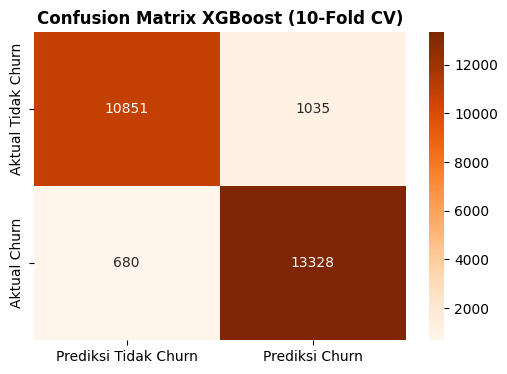

In [18]:
# =============================================================================
# CELL 12: EVALUASI MENDALAM KHUSUS MODEL XGBOOST
# =============================================================================
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("🔄 Menyiapkan Evaluasi untuk XGBOOST...")

# 1. Inisialisasi Model XGBoost
# Menggunakan parameter standar, bisa disesuaikan jika sudah di-tuning
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# 2. Proses Cross-Validation (K-Fold = 10 Stratified)
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores_xgb = cross_val_score(xgb_model, X_train_scaled, y_train, cv=skf, scoring='accuracy')

print("\n" + "="*60)
print("📊 HASIL CROSS-VALIDATION (10-Fold) - XGBOOST")
print("="*60)
print(f"Rata-rata Akurasi      : {cv_scores_xgb.mean():.4f} (+/- {cv_scores_xgb.std() * 2:.4f})")

# 3. Prediksi dan Metrik (Sensitivity & Specificity)
y_pred_cv_xgb = cross_val_predict(xgb_model, X_train_scaled, y_train, cv=skf)
cm_xgb = confusion_matrix(y_train, y_pred_cv_xgb)
tn_x, fp_x, fn_x, tp_x = cm_xgb.ravel()

sensitivity_xgb = tp_x / (tp_x + fn_x)
specificity_xgb = tn_x / (tn_x + fp_x)

print("\n" + "="*60)
print("📈 METRIK EVALUASI: SENSITIVITY & SPECIFICITY - XGBOOST")
print("="*60)
print(f"Sensitivity (Recall Positif) : {sensitivity_xgb:.4f} ({sensitivity_xgb*100:.1f}%)")
print(f"Specificity (Recall Negatif) : {specificity_xgb:.4f} ({specificity_xgb*100:.1f}%)")

# Visualisasi Confusion Matrix XGBoost
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Prediksi Tidak Churn', 'Prediksi Churn'], 
            yticklabels=['Aktual Tidak Churn', 'Aktual Churn'])
plt.title('Confusion Matrix XGBoost (10-Fold CV)', fontweight='bold')
plt.show()


🧠 CELL 14: TRAINING ARTIFICIAL NEURAL NETWORK (ANN)

📐 Jumlah fitur input  : 24
📦 Jumlah data train   : 25894
📦 Jumlah data test    : 11098

🏗️  Arsitektur ANN:
ChurnANNLogits(
  (network): Sequential(
    (0): Linear(in_features=24, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Linear(in_features=32, out_features=1, bias=True)
  )
)

⚖️  Class ratio (neg/pos) : 0.85

🚀 Mulai training selama 30 epoch...

   Epoch [05/30] | Train Loss: 0.2344 | Val Loss: 0.2119
   Epoch [10/30] | Train Loss: 0.1908 | Val Loss: 0.1681
   Epoch [15/30] | Train Loss: 0.1781 | Val Loss: 0.1619
  

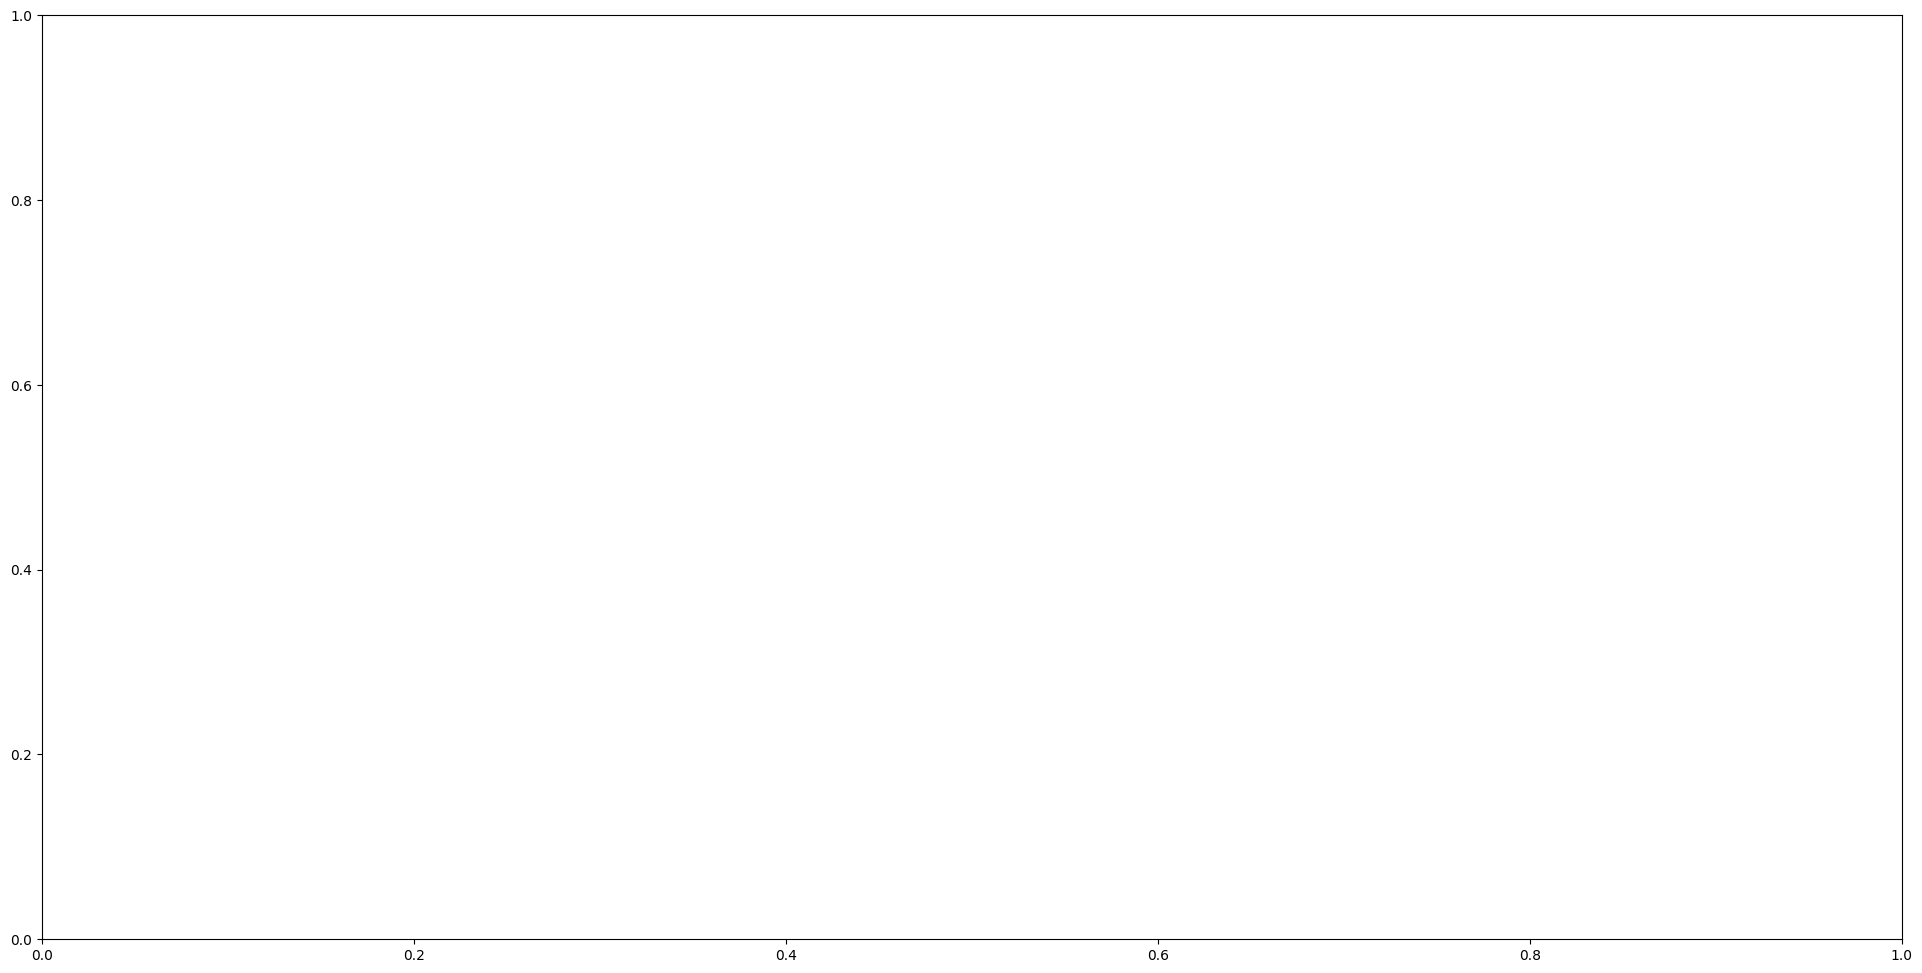

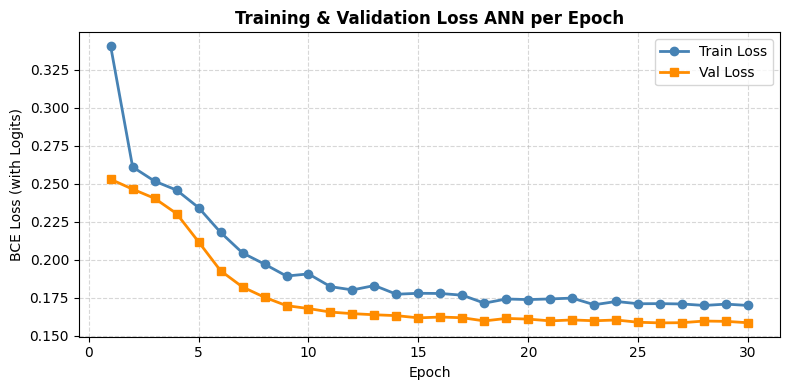


💡 Grafik menunjukkan pergerakan loss (Train vs Val) untuk menganalisis konvergensi/divergensi dan potensi early stopping.


In [ ]:
# =============================================================================
# CELL 14: ARTIFICIAL NEURAL NETWORK (ANN) - TRAINING
# =============================================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

print("=" * 60)
print("🧠 CELL 14: TRAINING ARTIFICIAL NEURAL NETWORK (ANN)")
print("=" * 60)

# ── 1. Konversi data ke PyTorch Tensor ─────────────────────────
X_train_t = torch.FloatTensor(X_train_scaled)
y_train_t = torch.FloatTensor(y_train.values).unsqueeze(1)
X_test_t  = torch.FloatTensor(X_test_scaled)
y_test_t  = torch.FloatTensor(y_test.values).unsqueeze(1)

train_ds = TensorDataset(X_train_t, y_train_t)
train_dl = DataLoader(train_ds, batch_size=256, shuffle=True)


input_dim = X_train_scaled.shape[1]
print(f"\n📐 Jumlah fitur input  : {input_dim}")
print(f"📦 Jumlah data train   : {X_train_scaled.shape[0]}")
print(f"📦 Jumlah data test    : {X_test_scaled.shape[0]}")

# ── 2. Arsitektur ANN (output = logits, tanpa Sigmoid) ────────
class ChurnANNLogits(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)   # logits – Sigmoid dihandle BCEWithLogitsLoss
        )

    def forward(self, x):
        return self.network(x)

device    = torch.device('cpu')
ann_model = ChurnANNLogits(input_dim).to(device)

print("\n🏗️  Arsitektur ANN:")
print(ann_model)

# ── 3. Loss function & optimizer ──────────────────────────────
n_neg      = (y_train == 0).sum()
n_pos      = (y_train == 1).sum()
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32)
print(f"\n⚖️  Class ratio (neg/pos) : {pos_weight.item():.2f}")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(ann_model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

# ── 4. Training loop ──────────────────────────────────────────
EPOCHS       = 30
history_loss = []
history_val_loss = []

print(f"\n🚀 Mulai training selama {EPOCHS} epoch...\n")
for epoch in range(EPOCHS):
    ann_model.train()
    epoch_loss = 0.0
    for X_batch, y_batch in train_dl:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = ann_model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * X_batch.size(0)
    scheduler.step()
    avg_loss = epoch_loss / len(train_ds)
    history_loss.append(avg_loss)
    
    ann_model.eval()
    with torch.no_grad():
        val_logits = ann_model(X_test_t.to(device))
        val_loss   = criterion(val_logits, y_test_t.to(device))
        history_val_loss.append(val_loss.item())

    if (epoch + 1) % 5 == 0:
        print(f"   Epoch [{epoch+1:02d}/{EPOCHS}] | Train Loss: {avg_loss:.4f} | Val Loss: {val_loss.item():.4f}")

print("\n✅ Training ANN selesai!")

# ── 5. Plot training & validation loss ──────────────────────────
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS+1), history_loss, marker='o', color='steelblue', linewidth=2, label='Train Loss')
plt.plot(range(1, EPOCHS+1), history_val_loss, marker='s', color='darkorange', linewidth=2, label='Val Loss')
plt.title('Training & Validation Loss ANN per Epoch', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss (with Logits)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
print("\n💡 Grafik menunjukkan pergerakan loss (Train vs Val) untuk menganalisis konvergensi/divergensi dan potensi early stopping.")


📊 CELL 15: EVALUASI ANN & PERBANDINGAN SEMUA MODEL

📋 Classification Report — ANN (PyTorch):
              precision    recall  f1-score   support

 Tidak Churn       0.92      0.93      0.92      5094
       Churn       0.94      0.93      0.94      6004

    accuracy                           0.93     11098
   macro avg       0.93      0.93      0.93     11098
weighted avg       0.93      0.93      0.93     11098

AUC-ROC       : 0.9749
Sensitivity   : 0.9329 (93.3%)
Specificity   : 0.9283 (92.8%)

🏆 TABEL PERBANDINGAN SEMUA MODEL
                     Accuracy  F1-Score  AUC-ROC
Model                                           
XGBoost                0.9338    0.9396   0.9760
ANN (PyTorch)          0.9308    0.9358   0.9749
Random Forest          0.9321    0.9363   0.9745
Logistic Regression    0.8613    0.8648   0.9441

🥇 Model terbaik (AUC-ROC): XGBoost — 0.9760


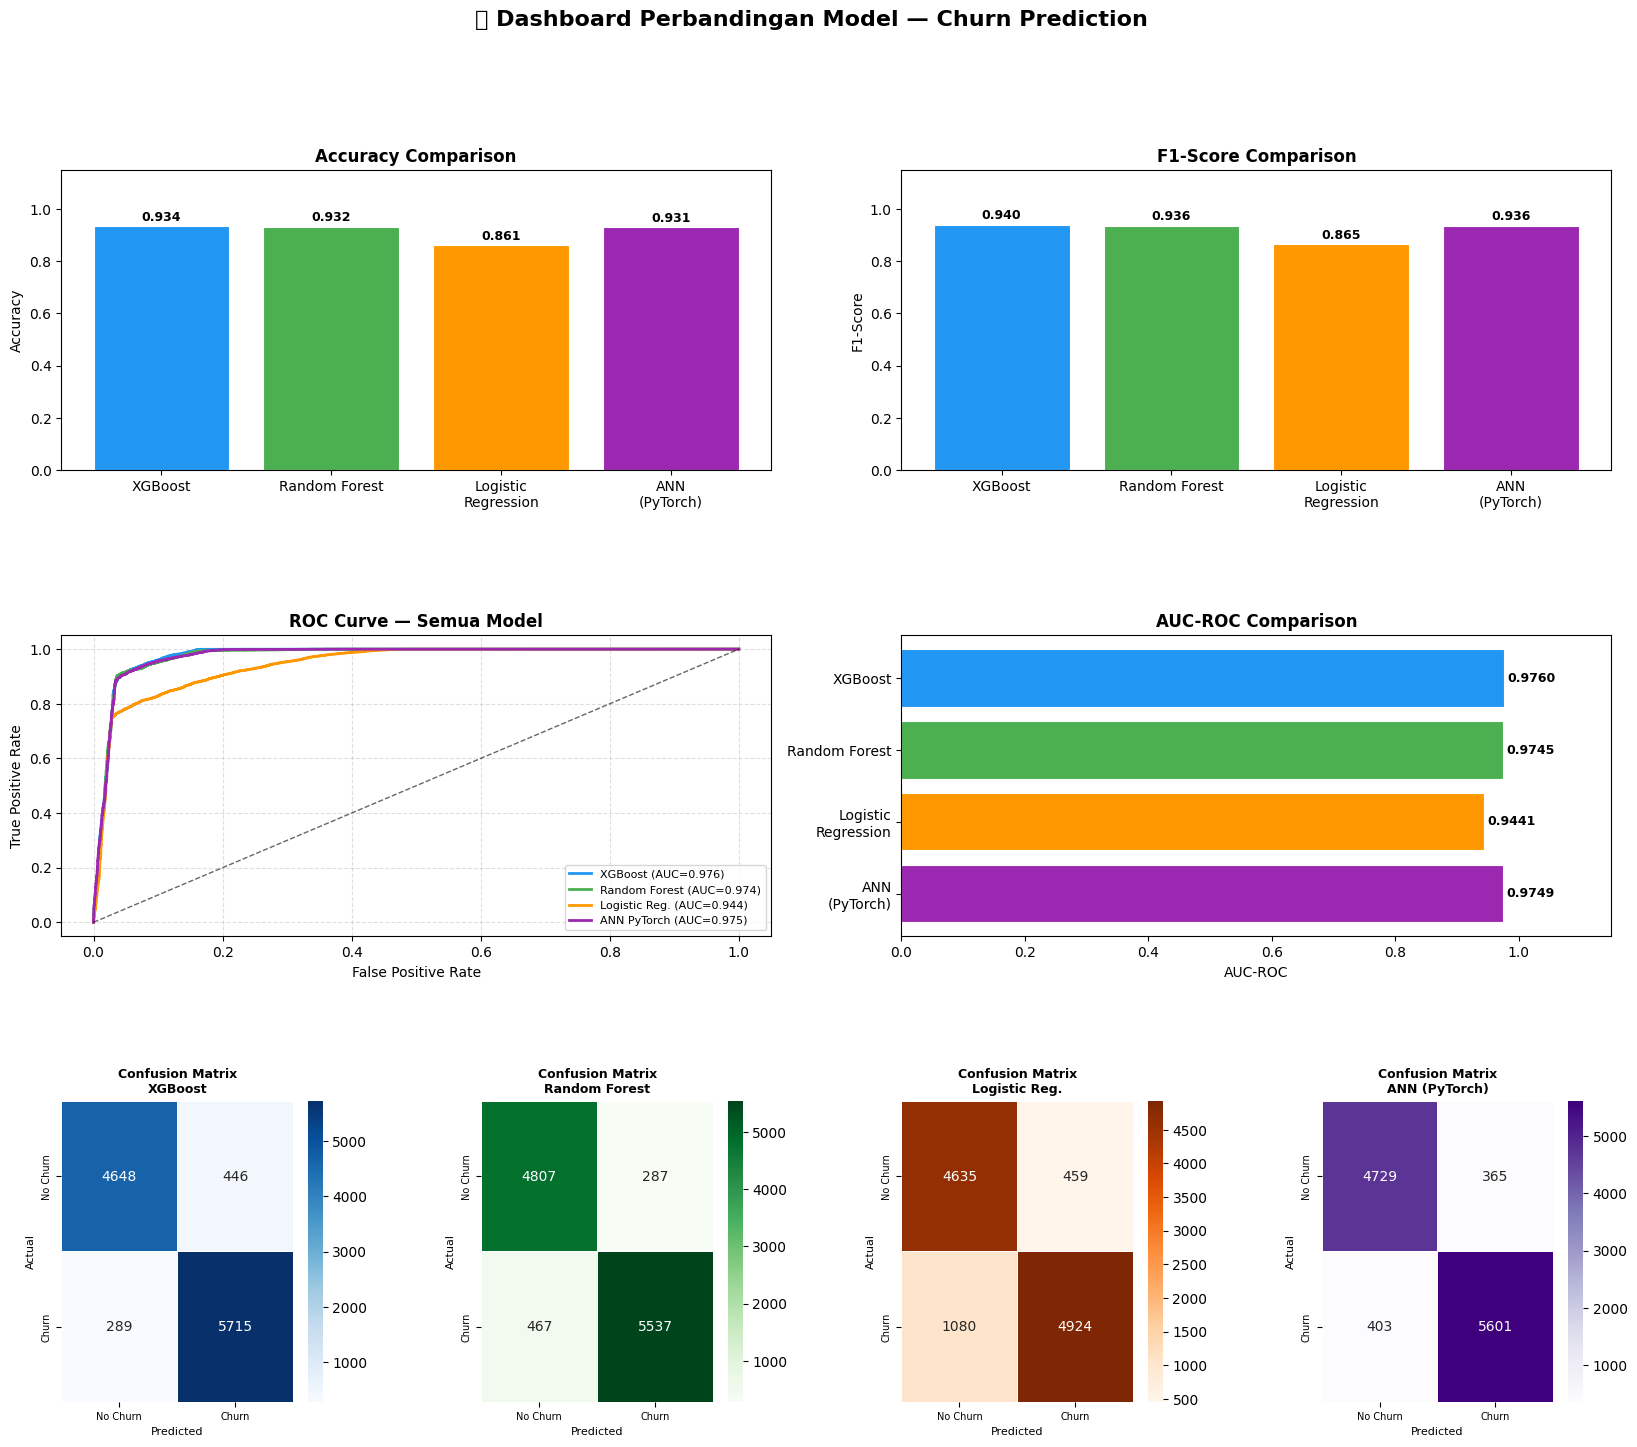


✅ Dashboard perbandingan model selesai!
💾 Grafik disimpan ke '../reports/model_comparison_dashboard.png'

💡 INSIGHT PERBANDINGAN
  #1 XGBoost                | Acc=0.9338 | F1=0.9396 | AUC=0.9760
  #2 ANN (PyTorch)          | Acc=0.9308 | F1=0.9358 | AUC=0.9749
  #3 Random Forest          | Acc=0.9321 | F1=0.9363 | AUC=0.9745
  #4 Logistic Regression    | Acc=0.8613 | F1=0.8648 | AUC=0.9441

  🔑 ANN (PyTorch) digunakan sebagai DEEP LEARNING baseline.
  📌 Model tree-based (XGBoost/RF) umumnya lebih cepat & sering
     mengungguli ANN pada data tabular berukuran sedang.
  📌 ANN dapat ditingkatkan dengan: lebih banyak epoch,
     hyperparameter tuning, atau arsitektur yang lebih dalam.


In [21]:
# =============================================================================
# CELL 15: EVALUASI ANN + PERBANDINGAN SEMUA MODEL
# =============================================================================
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import (
    classification_report, roc_auc_score,
    confusion_matrix, accuracy_score, f1_score, roc_curve
)

print("=" * 60)
print("📊 CELL 15: EVALUASI ANN & PERBANDINGAN SEMUA MODEL")
print("=" * 60)

# ── 1. Prediksi ANN pada data test ────────────────────────────
ann_model.eval()
with torch.no_grad():
    logits_test = ann_model(X_test_t.to(device))
    proba_ann   = torch.sigmoid(logits_test).cpu().numpy().flatten()
    pred_ann    = (proba_ann >= 0.5).astype(int)

# ── 2. Metrik ANN ─────────────────────────────────────────────
acc_ann  = accuracy_score(y_test, pred_ann)
f1_ann   = f1_score(y_test, pred_ann)
auc_ann  = roc_auc_score(y_test, proba_ann)
cm_ann   = confusion_matrix(y_test, pred_ann)

tn_a, fp_a, fn_a, tp_a = cm_ann.ravel()
sensitivity_ann = tp_a / (tp_a + fn_a)
specificity_ann = tn_a / (tn_a + fp_a)

print("\n📋 Classification Report — ANN (PyTorch):")
print(classification_report(y_test, pred_ann, target_names=['Tidak Churn', 'Churn']))
print(f"AUC-ROC       : {auc_ann:.4f}")
print(f"Sensitivity   : {sensitivity_ann:.4f} ({sensitivity_ann*100:.1f}%)")
print(f"Specificity   : {specificity_ann:.4f} ({specificity_ann*100:.1f}%)")

# ── 3. Kumpulkan metrik semua model ───────────────────────────
# XGBoost
proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]
pred_xgb  = (proba_xgb >= 0.5).astype(int)
acc_xgb   = accuracy_score(y_test, pred_xgb)
f1_xgb    = f1_score(y_test, pred_xgb)
auc_xgb   = roc_auc_score(y_test, proba_xgb)
cm_xgb_ev = confusion_matrix(y_test, pred_xgb)

# Logistic Regression
proba_lr  = lr_model.predict_proba(X_test_scaled)[:, 1]
pred_lr   = lr_model.predict(X_test_scaled)
acc_lr    = accuracy_score(y_test, pred_lr)
f1_lr     = f1_score(y_test, pred_lr)
auc_lr    = roc_auc_score(y_test, proba_lr)
cm_lr_ev  = confusion_matrix(y_test, pred_lr)

# Random Forest
proba_rf  = rf_model.predict_proba(X_test_scaled)[:, 1]
pred_rf   = rf_model.predict(X_test_scaled)
acc_rf    = accuracy_score(y_test, pred_rf)
f1_rf     = f1_score(y_test, pred_rf)
auc_rf    = roc_auc_score(y_test, proba_rf)
cm_rf_ev  = confusion_matrix(y_test, pred_rf)

# ── 4. Tabel Ringkasan ────────────────────────────────────────
comparison_data = {
    'Model':     ['XGBoost', 'Random Forest', 'Logistic Regression', 'ANN (PyTorch)'],
    'Accuracy':  [acc_xgb, acc_rf, acc_lr, acc_ann],
    'F1-Score':  [f1_xgb,  f1_rf,  f1_lr,  f1_ann],
    'AUC-ROC':   [auc_xgb, auc_rf, auc_lr, auc_ann],
}
df_cmp = pd.DataFrame(comparison_data).set_index('Model')
df_cmp = df_cmp.sort_values('AUC-ROC', ascending=False)

print("\n" + "=" * 60)
print("🏆 TABEL PERBANDINGAN SEMUA MODEL")
print("=" * 60)
print(df_cmp.to_string(float_format=lambda x: f"{x:.4f}"))

best_model = df_cmp['AUC-ROC'].idxmax()
print(f"\n🥇 Model terbaik (AUC-ROC): {best_model} — {df_cmp.loc[best_model, 'AUC-ROC']:.4f}")

# ── 5. Dashboard Visualisasi ──────────────────────────────────
MODELS   = ['XGBoost', 'Random Forest', 'Logistic\nRegression', 'ANN\n(PyTorch)']
ACC_VALS = [acc_xgb, acc_rf, acc_lr, acc_ann]
F1_VALS  = [f1_xgb,  f1_rf,  f1_lr,  f1_ann]
AUC_VALS = [auc_xgb, auc_rf, auc_lr, auc_ann]
COLORS   = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

fig = plt.figure(figsize=(20, 16))
fig.suptitle('📊 Dashboard Perbandingan Model — Churn Prediction',
             fontsize=16, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.45)

# 5a. Bar — Accuracy
ax1 = fig.add_subplot(gs[0, 0:2])
bars1 = ax1.bar(MODELS, ACC_VALS, color=COLORS, edgecolor='white', linewidth=0.8)
ax1.set_title('Accuracy Comparison', fontweight='bold')
ax1.set_ylim(0, 1.15)
ax1.set_ylabel('Accuracy')
for bar, v in zip(bars1, ACC_VALS):
    ax1.text(bar.get_x() + bar.get_width()/2, v + 0.01,
             f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 5b. Bar — F1-Score
ax2 = fig.add_subplot(gs[0, 2:4])
bars2 = ax2.bar(MODELS, F1_VALS, color=COLORS, edgecolor='white', linewidth=0.8)
ax2.set_title('F1-Score Comparison', fontweight='bold')
ax2.set_ylim(0, 1.15)
ax2.set_ylabel('F1-Score')
for bar, v in zip(bars2, F1_VALS):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.01,
             f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 5c. ROC Curves
ax3 = fig.add_subplot(gs[1, 0:2])
for proba, label, color in [
    (proba_xgb, f'XGBoost (AUC={auc_xgb:.3f})',         '#2196F3'),
    (proba_rf,  f'Random Forest (AUC={auc_rf:.3f})',     '#4CAF50'),
    (proba_lr,  f'Logistic Reg. (AUC={auc_lr:.3f})',     '#FF9800'),
    (proba_ann, f'ANN PyTorch (AUC={auc_ann:.3f})',      '#9C27B0'),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax3.plot(fpr, tpr, label=label, linewidth=2, color=color)
ax3.plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.6)
ax3.set_title('ROC Curve — Semua Model', fontweight='bold')
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.legend(fontsize=8, loc='lower right')
ax3.grid(True, linestyle='--', alpha=0.4)

# 5d. AUC-ROC Horizontal Bar
ax4 = fig.add_subplot(gs[1, 2:4])
bars4 = ax4.barh(MODELS[::-1], AUC_VALS[::-1],
                 color=COLORS[::-1], edgecolor='white', linewidth=0.8)
ax4.set_title('AUC-ROC Comparison', fontweight='bold')
ax4.set_xlim(0, 1.15)
ax4.set_xlabel('AUC-ROC')
for bar, v in zip(bars4, AUC_VALS[::-1]):
    ax4.text(v + 0.005, bar.get_y() + bar.get_height()/2,
             f'{v:.4f}', ha='left', va='center', fontsize=9, fontweight='bold')

# 5e. Confusion Matrices — 4 model
cms_all   = [cm_xgb_ev, cm_rf_ev, cm_lr_ev, cm_ann]
clbls_all = ['XGBoost', 'Random Forest', 'Logistic Reg.', 'ANN (PyTorch)']
cmaps_all = ['Blues', 'Greens', 'Oranges', 'Purples']

for i, (cm_i, lbl, cmap) in enumerate(zip(cms_all, clbls_all, cmaps_all)):
    ax = fig.add_subplot(gs[2, i])
    sns.heatmap(cm_i, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'],
                linewidths=0.5, linecolor='white')
    ax.set_title(f'Confusion Matrix\n{lbl}', fontweight='bold', fontsize=9)
    ax.set_xlabel('Predicted', fontsize=8)
    ax.set_ylabel('Actual', fontsize=8)
    ax.tick_params(axis='both', labelsize=7)

plt.savefig('../reports/model_comparison_dashboard.png', dpi=150,
            bbox_inches='tight')
plt.show()

print("\n✅ Dashboard perbandingan model selesai!")
print("💾 Grafik disimpan ke '../reports/model_comparison_dashboard.png'")

# ── 6. Insight Ringkas ────────────────────────────────────────
print("\n" + "=" * 60)
print("💡 INSIGHT PERBANDINGAN")
print("=" * 60)
for idx, row in df_cmp.iterrows():
    rank = list(df_cmp.index).index(idx) + 1
    print(f"  #{rank} {idx:<22} | Acc={row['Accuracy']:.4f} | F1={row['F1-Score']:.4f} | AUC={row['AUC-ROC']:.4f}")
print()
print("  🔑 ANN (PyTorch) digunakan sebagai DEEP LEARNING baseline.")
print("  📌 Model tree-based (XGBoost/RF) umumnya lebih cepat & sering")
print("     mengungguli ANN pada data tabular berukuran sedang.")
print("  📌 ANN dapat ditingkatkan dengan: lebih banyak epoch,")
print("     hyperparameter tuning, atau arsitektur yang lebih dalam.")


 CLASS IMBALANCE - PENANGANAN DENGAN XGBOOST

 Distribusi Kelas Dataset:
  Total sampel    : 36,992
  Churn (1)       : 20,012 (54.1%)
  Tidak Churn (0) : 16,980 (45.9%)
  scale_pos_weight ideal = 0.8485  (jumlah_neg / jumlah_pos)

 Kedua model XGBoost selesai dilatih!

 PERBANDINGAN METRIK SEMUA SKENARIO
                           Accuracy  Precision  Recall  F1-Score  AUC-ROC    TP   FN
Label                                                                               
Default (th=0.5)             0.9337     0.9295  0.9494    0.9394   0.9765  5700  304
scale_pos_weight (th=0.5)    0.9338     0.9383  0.9394    0.9388   0.9763  5640  364
Default (th=0.3)             0.9298     0.8910  0.9915    0.9386   0.9765  5953   51
scale_pos_weight (th=0.3)    0.9303     0.8940  0.9885    0.9389   0.9763  5935   69

  TP = True Positive  -> Churn BERHASIL terdeteksi (makin banyak makin baik)
  FN = False Negative -> Churn TERLEWATKAN          (makin sedikit makin baik)


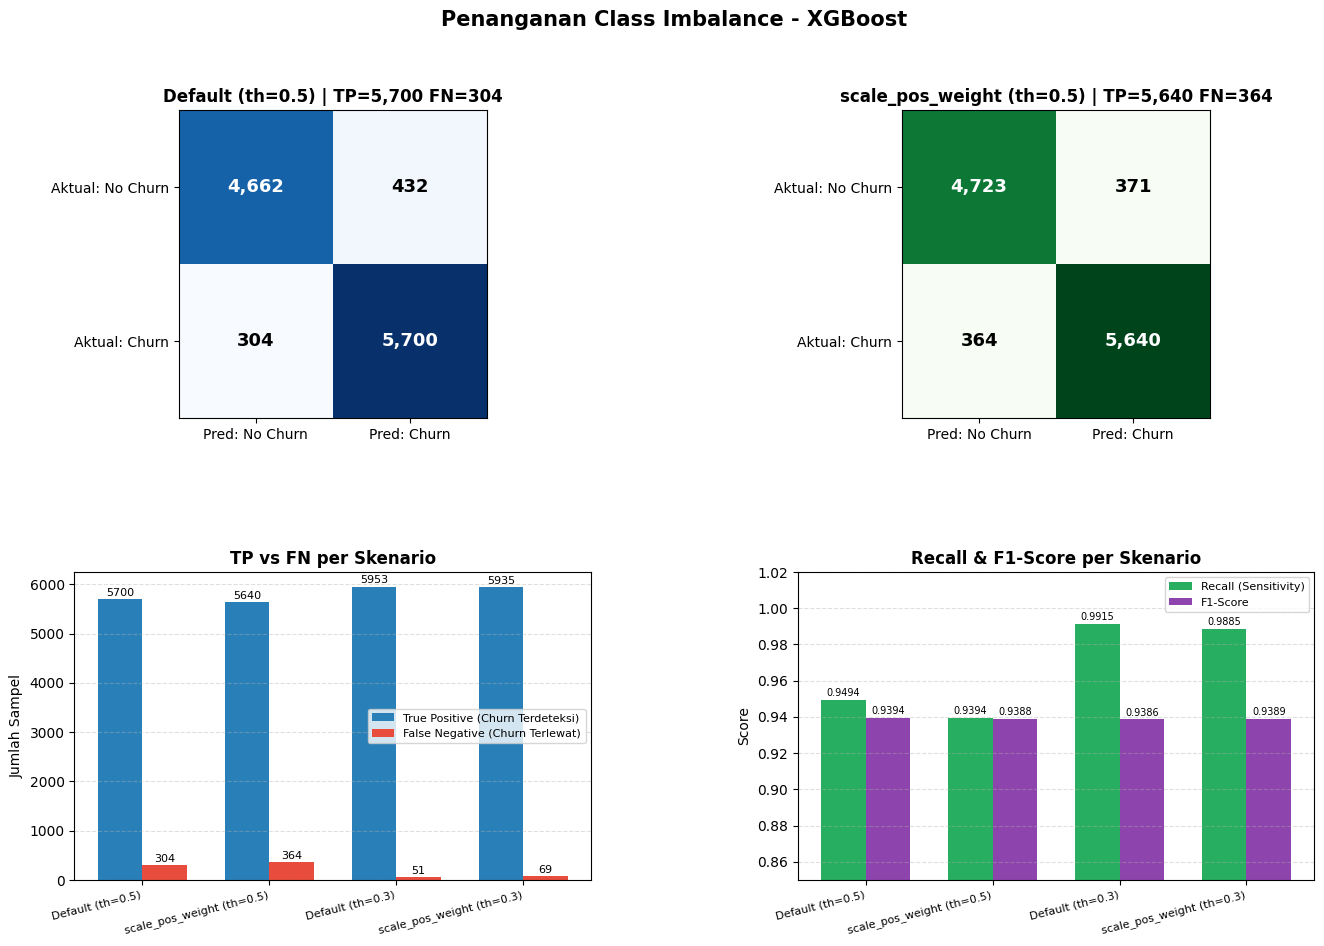

  Grafik disimpan ke reports/imbalance_xgboost_comparison.png

 THRESHOLD SWEEP - XGBoost + scale_pos_weight

              TP   FN  Recall  Precision  F1-Score
Threshold                                        
0.20       5985   19  0.9968     0.8840    0.9371
0.25       5966   38  0.9937     0.8885    0.9381
0.30       5935   69  0.9885     0.8940    0.9389
0.35       5881  123  0.9795     0.9012    0.9387
0.40       5808  196  0.9674     0.9122    0.9390
0.45       5724  280  0.9534     0.9249    0.9389
0.50       5640  364  0.9394     0.9383    0.9388
0.55       5583  421  0.9299     0.9493    0.9395
0.60       5536  468  0.9221     0.9565    0.9389
0.65       5503  501  0.9166     0.9604    0.9380
0.70       5479  525  0.9126     0.9644    0.9378
0.75       5454  550  0.9084     0.9663    0.9365
0.80       5436  568  0.9054     0.9674    0.9354

 Threshold OPTIMAL (F1 max) : 0.55
  TP (Churn Terdeteksi)     : 5,583
  FN (Churn Terlewat)       : 421
  Recall                    : 0.9

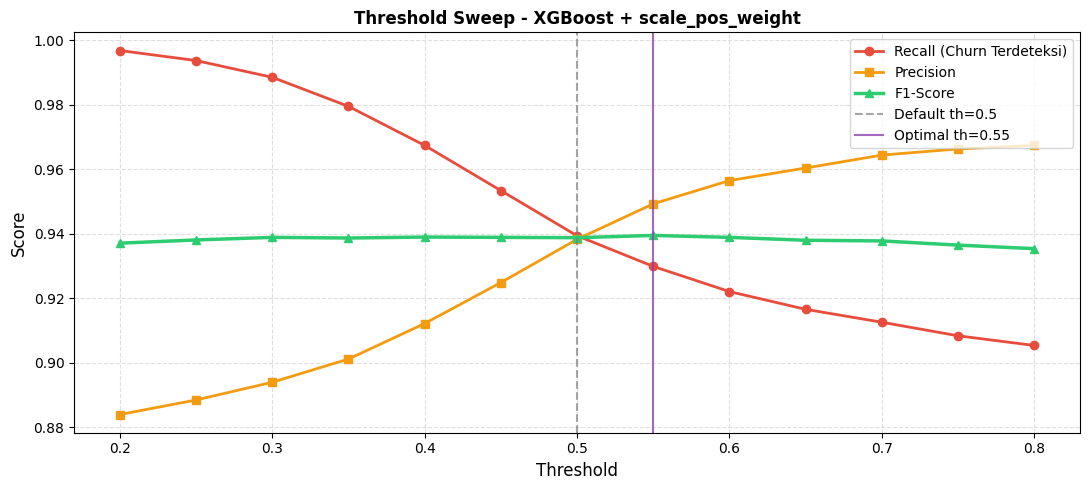

  Grafik disimpan ke reports/threshold_sweep_xgboost.png

 KESIMPULAN PENANGANAN CLASS IMBALANCE - XGBOOST

  TEKNIK 1 - scale_pos_weight
  Rumus   : scale_pos_weight = jumlah_negatif / jumlah_positif
  Cara    : XGBoost memberi BOBOT LEBIH TINGGI pada kelas Churn
            sehingga error pada kelas ini dihitung lebih berat.
  Efek    : Recall naik, model lebih berani prediksi Churn.

  TEKNIK 2 - Threshold Tuning
  Default : Threshold = 0.5 (model tebak Churn jika prob >= 50%)
  Solusi  : Turunkan threshold (mis. ke 0.3 atau 0.4)
  Efek    : TP (Churn terdeteksi) NAIK, FN (Churn terlewat) TURUN.
  Trade-off: Precision bisa turun sedikit (FP naik).

  KOMBINASI TERBAIK:
  scale_pos_weight + Threshold Tuning bekerja di dua level:
  - Level training : model lebih peduli kelas Churn
  - Level evaluasi : batas keputusan disesuaikan kebutuhan bisnis

Selesai! Cell 17 berhasil diperbarui.


In [22]:
# =============================================================================
# CELL 17: CLASS IMBALANCE - PENANGANAN DENGAN XGBOOST
# =============================================================================
# Fokus: 3 teknik menangani imbalance khusus XGBoost:
#   1. XGBoost Default (tanpa penanganan)
#   2. scale_pos_weight  (class weighting bawaan XGBoost)
#   3. Threshold Tuning  (mengubah batas keputusan)
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from xgboost import XGBClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, f1_score,
    roc_auc_score, recall_score, precision_score
)

print("=" * 70)
print(" CLASS IMBALANCE - PENANGANAN DENGAN XGBOOST")
print("=" * 70)

# ── 1. CEK DISTRIBUSI KELAS ──────────────────────────────────────────
n_total    = len(y_train) + len(y_test)
n_churn    = int((y_train == 1).sum() + (y_test == 1).sum())
n_no_churn = int((y_train == 0).sum() + (y_test == 0).sum())
spw        = n_no_churn / n_churn  # scale_pos_weight ideal = neg/pos

print(f"\n Distribusi Kelas Dataset:")
print(f"  Total sampel    : {n_total:,}")
print(f"  Churn (1)       : {n_churn:,} ({n_churn/n_total*100:.1f}%)")
print(f"  Tidak Churn (0) : {n_no_churn:,} ({n_no_churn/n_total*100:.1f}%)")
print(f"  scale_pos_weight ideal = {spw:.4f}  (jumlah_neg / jumlah_pos)")

# ── 2. LATIH 2 MODEL XGBOOST ─────────────────────────────────────────
# Model A: Default – tanpa penanganan imbalance
xgb_default = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric="logloss", random_state=42, verbosity=0
)
xgb_default.fit(X_train_scaled, y_train)

# Model B: scale_pos_weight aktif
xgb_weighted = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw,
    eval_metric="logloss", random_state=42, verbosity=0
)
xgb_weighted.fit(X_train_scaled, y_train)

print("\n Kedua model XGBoost selesai dilatih!")

# ── 3. HELPER FUNGSI METRIK ──────────────────────────────────────────
def get_metrics(model, X, y, threshold=0.5, label=""):
    proba = model.predict_proba(X)[:, 1]
    pred  = (proba >= threshold).astype(int)
    cm    = confusion_matrix(y, pred)
    tn_, fp_, fn_, tp_ = cm.ravel()
    return {
        "Label":     label,
        "Threshold": threshold,
        "Accuracy":  round(accuracy_score(y, pred), 4),
        "Precision": round(precision_score(y, pred, zero_division=0), 4),
        "Recall":    round(recall_score(y, pred, zero_division=0), 4),
        "F1-Score":  round(f1_score(y, pred, zero_division=0), 4),
        "AUC-ROC":   round(roc_auc_score(y, proba), 4),
        "TP": int(tp_), "FN": int(fn_),
        "TN": int(tn_), "FP": int(fp_),
    }

results = []
results.append(get_metrics(xgb_default,  X_test_scaled, y_test, 0.5, "Default (th=0.5)"))
results.append(get_metrics(xgb_weighted, X_test_scaled, y_test, 0.5, "scale_pos_weight (th=0.5)"))
results.append(get_metrics(xgb_default,  X_test_scaled, y_test, 0.3, "Default (th=0.3)"))
results.append(get_metrics(xgb_weighted, X_test_scaled, y_test, 0.3, "scale_pos_weight (th=0.3)"))

df_res = pd.DataFrame(results).set_index("Label")

# ── 4. TABEL PERBANDINGAN ────────────────────────────────────────────
print("\n" + "=" * 70)
print(" PERBANDINGAN METRIK SEMUA SKENARIO")
print("=" * 70)
cols_show = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC", "TP", "FN"]
print(df_res[cols_show].to_string())
print("\n  TP = True Positive  -> Churn BERHASIL terdeteksi (makin banyak makin baik)")
print("  FN = False Negative -> Churn TERLEWATKAN          (makin sedikit makin baik)")

# ── 5. VISUALISASI ───────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
fig.suptitle("Penanganan Class Imbalance - XGBoost", fontsize=15, fontweight="bold")
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.50, wspace=0.40)

# Panel 1: Confusion Matrix – Default
ax1  = fig.add_subplot(gs[0, 0])
r0   = results[0]
cm0  = [[r0["TN"], r0["FP"]], [r0["FN"], r0["TP"]]]
ax1.imshow(cm0, cmap="Blues")
ax1.set_title(f'Default (th=0.5) | TP={r0["TP"]:,} FN={r0["FN"]:,}', fontweight="bold")
for ii in range(2):
    for jj in range(2):
        ax1.text(jj, ii, f"{cm0[ii][jj]:,}", ha="center", va="center",
                 fontsize=13, fontweight="bold",
                 color="white" if cm0[ii][jj] > 3000 else "black")
ax1.set_xticks([0, 1]); ax1.set_yticks([0, 1])
ax1.set_xticklabels(["Pred: No Churn", "Pred: Churn"])
ax1.set_yticklabels(["Aktual: No Churn", "Aktual: Churn"])

# Panel 2: Confusion Matrix – scale_pos_weight
ax2  = fig.add_subplot(gs[0, 1])
r1   = results[1]
cm1  = [[r1["TN"], r1["FP"]], [r1["FN"], r1["TP"]]]
ax2.imshow(cm1, cmap="Greens")
ax2.set_title(f'scale_pos_weight (th=0.5) | TP={r1["TP"]:,} FN={r1["FN"]:,}', fontweight="bold")
for ii in range(2):
    for jj in range(2):
        ax2.text(jj, ii, f"{cm1[ii][jj]:,}", ha="center", va="center",
                 fontsize=13, fontweight="bold",
                 color="white" if cm1[ii][jj] > 3000 else "black")
ax2.set_xticks([0, 1]); ax2.set_yticks([0, 1])
ax2.set_xticklabels(["Pred: No Churn", "Pred: Churn"])
ax2.set_yticklabels(["Aktual: No Churn", "Aktual: Churn"])

# Panel 3: TP vs FN – semua skenario
ax3   = fig.add_subplot(gs[1, 0])
lbls  = [r["Label"] for r in results]
tps   = [r["TP"]    for r in results]
fns   = [r["FN"]    for r in results]
x_pos = np.arange(len(lbls))
w     = 0.35
b1 = ax3.bar(x_pos - w/2, tps, w, label="True Positive (Churn Terdeteksi)", color="#2980B9")
b2 = ax3.bar(x_pos + w/2, fns, w, label="False Negative (Churn Terlewat)",  color="#E74C3C")
ax3.set_xticks(x_pos)
ax3.set_xticklabels(lbls, rotation=14, ha="right", fontsize=8)
ax3.set_title("TP vs FN per Skenario", fontweight="bold")
ax3.set_ylabel("Jumlah Sampel")
ax3.legend(fontsize=8)
ax3.grid(axis="y", linestyle="--", alpha=0.4)
for bar in b1:
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
             str(int(bar.get_height())), ha="center", va="bottom", fontsize=8)
for bar in b2:
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
             str(int(bar.get_height())), ha="center", va="bottom", fontsize=8)

# Panel 4: Recall & F1 per skenario
ax4     = fig.add_subplot(gs[1, 1])
recalls = [r["Recall"]   for r in results]
f1s     = [r["F1-Score"] for r in results]
ax4.bar(x_pos - w/2, recalls, w, label="Recall (Sensitivity)", color="#27AE60")
ax4.bar(x_pos + w/2, f1s,     w, label="F1-Score",             color="#8E44AD")
ax4.set_xticks(x_pos)
ax4.set_xticklabels(lbls, rotation=14, ha="right", fontsize=8)
ax4.set_title("Recall & F1-Score per Skenario", fontweight="bold")
ax4.set_ylabel("Score")
ax4.set_ylim(0.85, 1.02)
ax4.legend(fontsize=8)
ax4.grid(axis="y", linestyle="--", alpha=0.4)
for p in ax4.patches:
    ax4.text(p.get_x()+p.get_width()/2, p.get_height()+0.001,
             f"{p.get_height():.4f}", ha="center", va="bottom", fontsize=7)

plt.savefig("../reports/imbalance_xgboost_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Grafik disimpan ke reports/imbalance_xgboost_comparison.png")

# ── 6. THRESHOLD SWEEP (scale_pos_weight model) ──────────────────────
print("\n" + "=" * 70)
print(" THRESHOLD SWEEP - XGBoost + scale_pos_weight")
print("=" * 70)

proba_w    = xgb_weighted.predict_proba(X_test_scaled)[:, 1]
sweep_data = []
for th in np.arange(0.20, 0.81, 0.05):
    th   = round(th, 2)
    pred = (proba_w >= th).astype(int)
    cm_  = confusion_matrix(y_test, pred)
    tn_, fp_, fn_, tp_ = cm_.ravel()
    sweep_data.append({
        "Threshold": th,
        "TP":        int(tp_),
        "FN":        int(fn_),
        "Recall":    round(recall_score(y_test, pred, zero_division=0), 4),
        "Precision": round(precision_score(y_test, pred, zero_division=0), 4),
        "F1-Score":  round(f1_score(y_test, pred, zero_division=0), 4),
    })

df_sweep = pd.DataFrame(sweep_data).set_index("Threshold")
print("\n", df_sweep.to_string())

best_th  = df_sweep["F1-Score"].idxmax()
best_row = df_sweep.loc[best_th]
print(f"\n Threshold OPTIMAL (F1 max) : {best_th}")
print(f"  TP (Churn Terdeteksi)     : {int(best_row['TP']):,}")
print(f"  FN (Churn Terlewat)       : {int(best_row['FN']):,}")
print(f"  Recall                    : {best_row['Recall']:.4f}")
print(f"  F1-Score                  : {best_row['F1-Score']:.4f}")

# Plot threshold sweep
fig2, ax5 = plt.subplots(figsize=(11, 5))
ax5.plot(df_sweep.index, df_sweep["Recall"],    marker="o", color="#E74C3C",
         linewidth=2, label="Recall (Churn Terdeteksi)")
ax5.plot(df_sweep.index, df_sweep["Precision"], marker="s", color="#F39C12",
         linewidth=2, label="Precision")
ax5.plot(df_sweep.index, df_sweep["F1-Score"],  marker="^", color="#2ECC71",
         linewidth=2.5, label="F1-Score")
ax5.axvline(x=0.5,     color="gray",    linestyle="--", alpha=0.7, label="Default th=0.5")
ax5.axvline(x=best_th, color="#8E44AD", linestyle="-",  alpha=0.8,
            label=f"Optimal th={best_th}")
ax5.set_xlabel("Threshold", fontsize=12)
ax5.set_ylabel("Score", fontsize=12)
ax5.set_title("Threshold Sweep - XGBoost + scale_pos_weight", fontweight="bold")
ax5.legend(fontsize=10)
ax5.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("../reports/threshold_sweep_xgboost.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Grafik disimpan ke reports/threshold_sweep_xgboost.png")

# ── 7. KESIMPULAN ────────────────────────────────────────────────────
print("\n" + "=" * 70)
print(" KESIMPULAN PENANGANAN CLASS IMBALANCE - XGBOOST")
print("=" * 70)
print("")
print("  TEKNIK 1 - scale_pos_weight")
print("  Rumus   : scale_pos_weight = jumlah_negatif / jumlah_positif")
print("  Cara    : XGBoost memberi BOBOT LEBIH TINGGI pada kelas Churn")
print("            sehingga error pada kelas ini dihitung lebih berat.")
print("  Efek    : Recall naik, model lebih berani prediksi Churn.")
print("")
print("  TEKNIK 2 - Threshold Tuning")
print("  Default : Threshold = 0.5 (model tebak Churn jika prob >= 50%)")
print("  Solusi  : Turunkan threshold (mis. ke 0.3 atau 0.4)")
print("  Efek    : TP (Churn terdeteksi) NAIK, FN (Churn terlewat) TURUN.")
print("  Trade-off: Precision bisa turun sedikit (FP naik).")
print("")
print("  KOMBINASI TERBAIK:")
print("  scale_pos_weight + Threshold Tuning bekerja di dua level:")
print("  - Level training : model lebih peduli kelas Churn")
print("  - Level evaluasi : batas keputusan disesuaikan kebutuhan bisnis")
print("")
print("Selesai! Cell 17 berhasil diperbarui.")


 CELL 18: INVESTIGASI FEATURE DOMINANCE & EXPLAINABILITY

 Apa itu Feature Dominance?
 --------------------------
 Bayangkan sebuah tim sepak bola. Jika 1 pemain selalu mencetak 80%
 dari semua gol, maka tim sangat bergantung padanya. Jika dia cedera,
 tim akan kalah. Begitu pula dengan model ML kita:
 plan_tier menyumbang ~80% importance -> model terlalu bergantung padanya.

 Yang akan kita selidiki:
 1. Apakah plan_tier 'bocoran' data? (Data Leakage)
 2. Seberapa penting SEBENARNYA setiap fitur? (Permutation Importance)
 3. Apa yang terjadi jika plan_tier dihapus?
 4. Adakah fitur yang 'kembar' (berkorelasi tinggi)?

 Total fitur : 24
 Nama fitur  : [np.str_('age'), np.str_('gender'), np.str_('region_category'), np.str_('joined_through_referral'), np.str_('preferred_offer_types'), np.str_('medium_of_operation'), np.str_('internet_option'), np.str_('days_since_last_login'), np.str_('avg_session_duration'), np.str_('avg_transaction_value'), np.str_('avg_frequency_login_days'), np.str_(

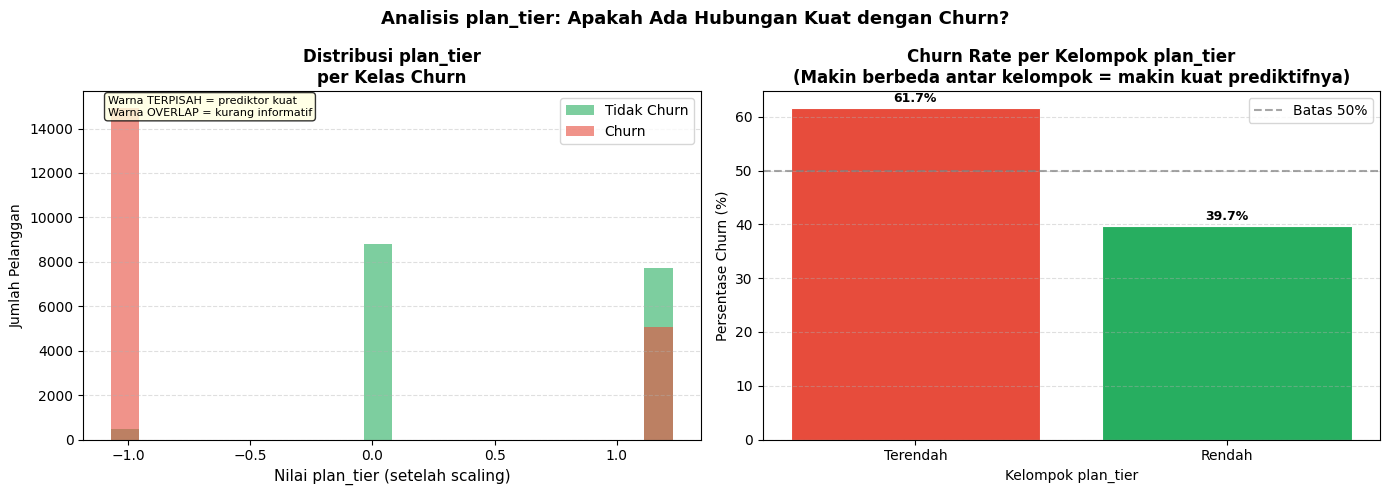

 Grafik disimpan ke reports/plan_tier_analysis.png

 CARA BACA GRAFIK:
 - Panel KIRI  : Jika 2 warna (hijau/merah) SANGAT TERPISAH
                  -> plan_tier memang prediktor kuat (bukan leakage)
                  Jika warna BANYAK OVERLAP -> mungkin ada leakage
 - Panel KANAN : Jika churn rate antar kelompok SANGAT BERBEDA
                  -> plan_tier sangat menentukan keputusan churn

 BAGIAN 2: XGBoost Importance vs Permutation Importance

 ADA DUA CARA MENGUKUR KEPENTINGAN FITUR:

 1. XGBoost Built-in Importance (yang selama ini kita pakai)
    Cara kerja: Hitung seberapa sering fitur dipakai memisahkan data
    Kelemahan : Bisa LEBAY untuk fitur dengan banyak nilai berbeda
                (plan_tier mungkin punya kardinalitas tinggi)

 2. Permutation Importance (lebih adil & lebih akurat)
    Cara kerja: Acak nilai 1 fitur, ukur seberapa PARAH performa turun
    Logika    : Kalau mengacak fitur X membuat model jauh lebih buruk,
                berarti fitur X memang sangat p

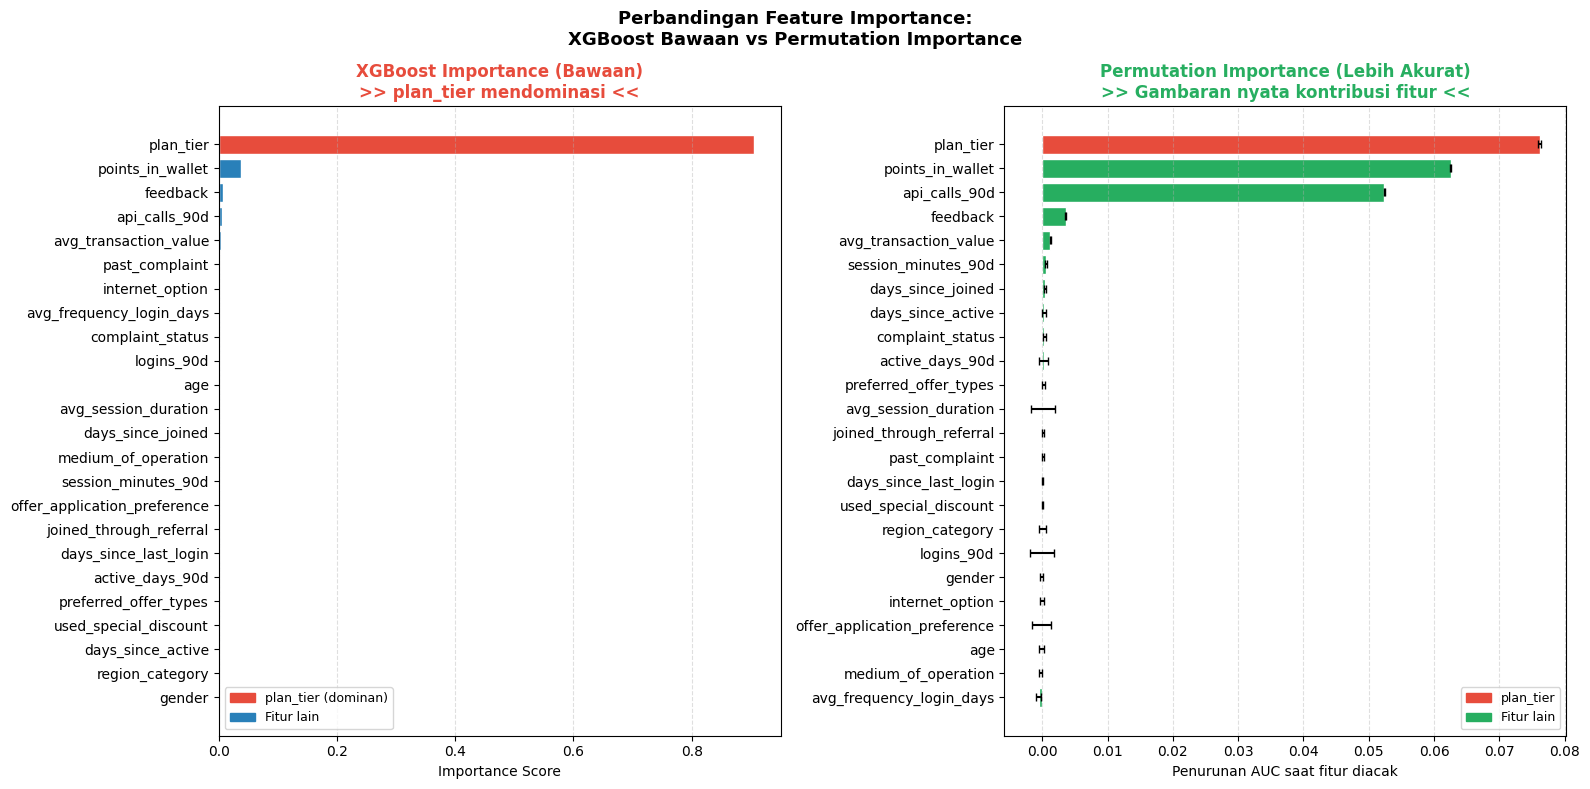

 Grafik disimpan ke reports/feature_importance_comparison.png

 CARA BACA PERMUTATION IMPORTANCE:
 - Angka = 'Jika fitur ini diacak, AUC model turun sebesar X'
 - Makin BESAR angkanya -> fitur makin PENTING
 - Garis error (|) pendek = stabil, panjang = tidak konsisten
 - Nilai NEGATIF = fitur tidak berguna (bahkan bisa mengganggu!)

 BAGIAN 3: EKSPERIMEN - Apa yang Terjadi Tanpa plan_tier?

 ANALOGI:
 Kita punya tim futsal 5 orang. Pemain A selalu cetak 80% gol.
 Pertanyaan: Kalau Pemain A absen, seberapa buruk tim kita?
 Jika tim HANCUR  -> Pemain A memang krusial, bergantung padanya
 Jika tim TETAP OK -> Pemain lain ternyata bisa kompensasi!

 Kita akan uji XGBoost TANPA plan_tier dan bandingkan hasilnya.
 Model tanpa plan_tier selesai dilatih!

 Hasil Perbandingan:
                 Accuracy F1-Score AUC-ROC
Model                                     
Dengan plan_tier   0.9338   0.9396  0.9760
Tanpa plan_tier    0.9327   0.9384  0.9762
Selisih            -0.11%   -0.11%  +0.02%

 VERD

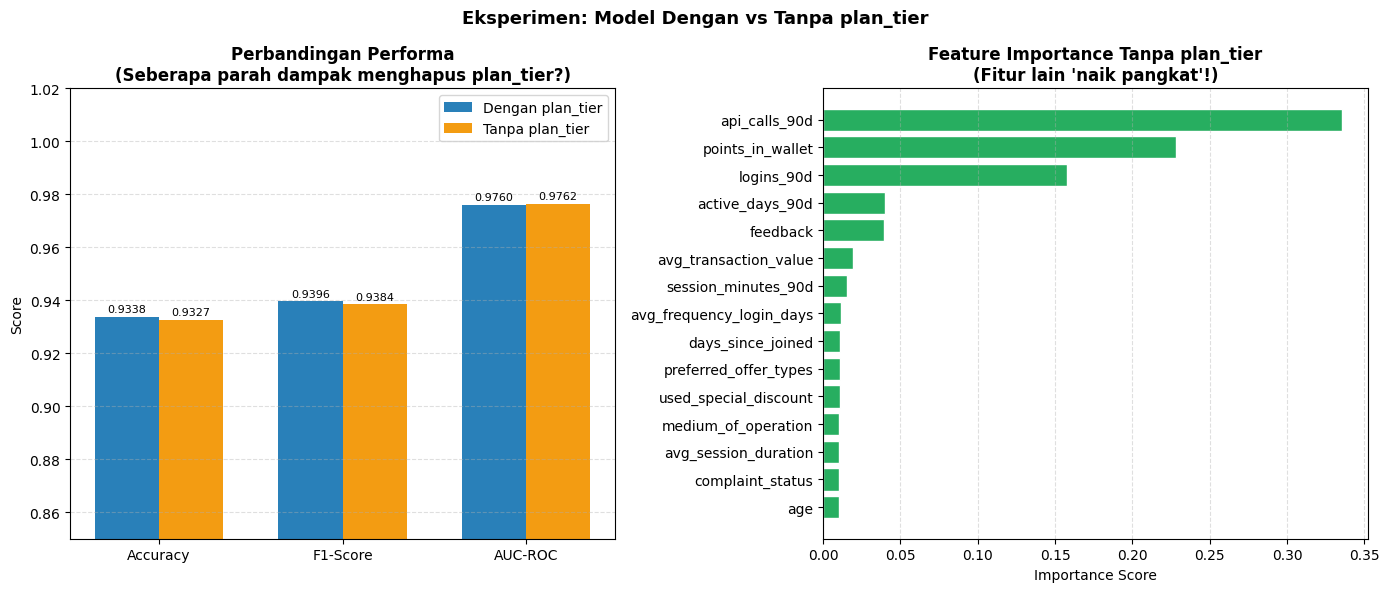

 Grafik disimpan ke reports/experiment_no_plan_tier.png

 BAGIAN 4: KORELASI ANTAR FITUR (Apakah Ada Fitur Kembar?)

 ANALOGI KORELASI:
 Jika Anda mengukur tinggi badan dalam CM dan INCH secara bersamaan,
 keduanya mengandung informasi yang SAMA persis. Memberikan keduanya
 ke model hanya membuang tempat dan membingungkan.

 Korelasi tinggi (mendekati 1.0 atau -1.0) antar dua fitur berarti
 mereka 'bercerita hal yang sama' -> salah satu bisa dihapus.


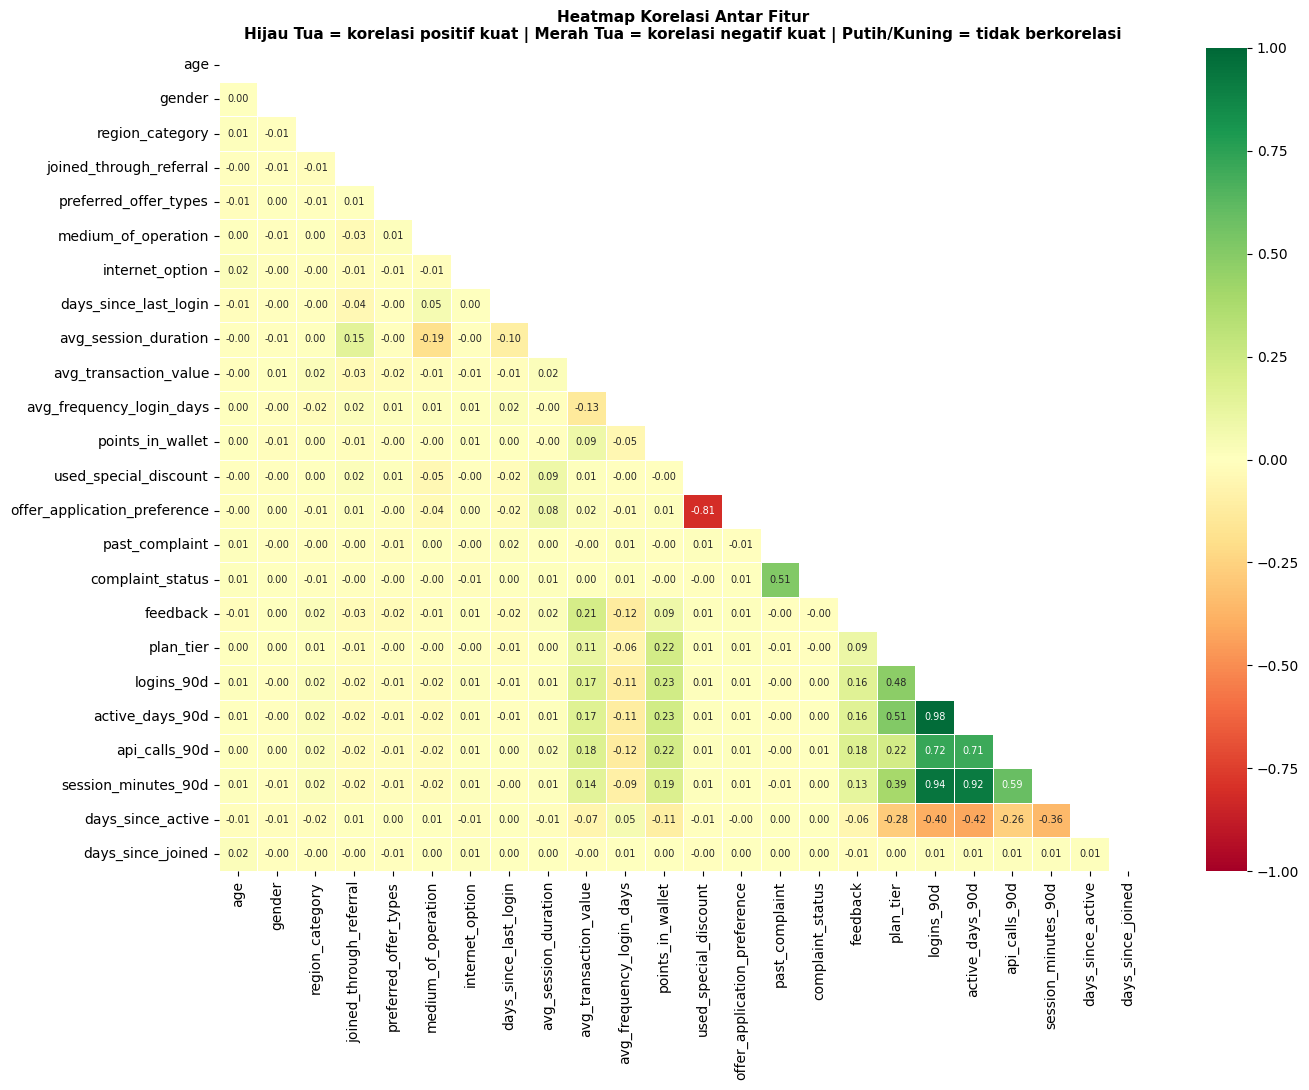

 Grafik disimpan ke reports/feature_correlation_heatmap.png

 Pasangan fitur berkorelasi tinggi (|r| >= 0.5):
              Fitur A                      Fitur B  Korelasi  |Korelasi|
           logins_90d              active_days_90d     0.984       0.984
           logins_90d          session_minutes_90d     0.941       0.941
      active_days_90d          session_minutes_90d     0.918       0.918
used_special_discount offer_application_preference    -0.812       0.812
           logins_90d                api_calls_90d     0.724       0.724
      active_days_90d                api_calls_90d     0.710       0.710
        api_calls_90d          session_minutes_90d     0.589       0.589
       past_complaint             complaint_status     0.514       0.514
            plan_tier              active_days_90d     0.511       0.511

 INTERPRETASI:
 - |Korelasi| >= 0.7 : Sangat mirip, pertimbangkan hapus salah satu
 - |Korelasi| 0.5-0.7: Cukup mirip, monitor performanya
 - |Korelasi| < 0.5 

In [23]:
# =============================================================================
# CELL 18: INVESTIGASI FEATURE DOMINANCE & EXPLAINABILITY
# =============================================================================
# Masalah: plan_tier mendominasi ~80% feature importance
# Tujuan : 1. Cek apakah ini data leakage
#           2. Gunakan Permutation Importance (lebih adil)
#           3. Uji model tanpa plan_tier
#           4. Korelasi antar fitur
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import warnings
warnings.filterwarnings("ignore")

C_RED    = "#E74C3C"
C_BLUE   = "#2980B9"
C_GREEN  = "#27AE60"
C_ORANGE = "#F39C12"

print("=" * 70)
print(" CELL 18: INVESTIGASI FEATURE DOMINANCE & EXPLAINABILITY")
print("=" * 70)
print("")
print(" Apa itu Feature Dominance?")
print(" --------------------------")
print(" Bayangkan sebuah tim sepak bola. Jika 1 pemain selalu mencetak 80%")
print(" dari semua gol, maka tim sangat bergantung padanya. Jika dia cedera,")
print(" tim akan kalah. Begitu pula dengan model ML kita:")
print(" plan_tier menyumbang ~80% importance -> model terlalu bergantung padanya.")
print("")
print(" Yang akan kita selidiki:")
print(" 1. Apakah plan_tier 'bocoran' data? (Data Leakage)")
print(" 2. Seberapa penting SEBENARNYA setiap fitur? (Permutation Importance)")
print(" 3. Apa yang terjadi jika plan_tier dihapus?")
print(" 4. Adakah fitur yang 'kembar' (berkorelasi tinggi)?")

# ── 0. SIAPKAN DATA ──────────────────────────────────────────────────
# Ambil nama fitur dari model XGBoost (selalu akurat, terlepas dari tipe X_train_scaled)
if hasattr(X_train_scaled, "columns"):
    feature_names = X_train_scaled.columns.tolist()
elif hasattr(xgb_model, "feature_names_in_") and xgb_model.feature_names_in_ is not None:
    feature_names = list(xgb_model.feature_names_in_)
else:
    feature_names = xgb_model.get_booster().feature_names

X_train_df = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_df  = pd.DataFrame(X_test_scaled,  columns=feature_names)

print(f"\n Total fitur : {len(feature_names)}")
print(f" Nama fitur  : {feature_names}")

# ── 1. CEK DATA LEAKAGE: DISTRIBUSI plan_tier vs CHURN ───────────────
print("\n" + "=" * 70)
print(" BAGIAN 1: CEK DATA LEAKAGE (Apakah plan_tier adalah 'bocoran'?)")
print("=" * 70)
print("")
print(" ANALOGI DATA LEAKAGE:")
print(" Bayangkan Anda diminta menebak siapa yang akan LULUS ujian.")
print(" Lalu Anda diberi tahu NILAI ujiannya duluan.")
print(" Tentu Anda bisa tebak dengan benar! Tapi di dunia nyata,")
print(" nilai ujian belum ada saat kita harus memprediksi.")
print("")
print(" Data Leakage terjadi jika plan_tier berubah SETELAH pelanggan")
print(" memutuskan untuk churn (misal: plan di-downgrade saat mau pergi).")
print(" Jika ini terjadi, model kita 'mencontek' dan tidak berguna di produksi!")

if "plan_tier" in feature_names:
    X_all = pd.concat([X_train_df, X_test_df], ignore_index=True)
    y_all = pd.concat([y_train.reset_index(drop=True),
                       y_test.reset_index(drop=True)], ignore_index=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Analisis plan_tier: Apakah Ada Hubungan Kuat dengan Churn?",
                 fontsize=13, fontweight="bold")

    churn_pt   = X_all.loc[y_all == 1, "plan_tier"]
    nochurn_pt = X_all.loc[y_all == 0, "plan_tier"]
    axes[0].hist(nochurn_pt, bins=20, alpha=0.6, color=C_GREEN, label="Tidak Churn")
    axes[0].hist(churn_pt,   bins=20, alpha=0.6, color=C_RED,   label="Churn")
    axes[0].set_xlabel("Nilai plan_tier (setelah scaling)", fontsize=11)
    axes[0].set_ylabel("Jumlah Pelanggan")
    axes[0].set_title("Distribusi plan_tier\nper Kelas Churn", fontweight="bold")
    axes[0].legend()
    axes[0].grid(axis="y", linestyle="--", alpha=0.4)
    axes[0].text(0.04, 0.93,
                 "Warna TERPISAH = prediktor kuat\nWarna OVERLAP = kurang informatif",
                 transform=axes[0].transAxes, fontsize=8,
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))

    X_all_copy = X_all.copy()
    X_all_copy["churn"] = y_all.values
    # Gunakan labels dinamis sesuai jumlah bin yang terbentuk
    plan_cut, plan_bins = pd.qcut(X_all_copy["plan_tier"], q=5,
                                   retbins=True, duplicates="drop")
    n_bins      = len(plan_bins) - 1
    base_labels = ["Terendah", "Rendah", "Sedang", "Tinggi", "Tertinggi"]
    dyn_labels  = base_labels[:n_bins]
    X_all_copy["plan_bucket"] = pd.qcut(
        X_all_copy["plan_tier"], q=5,
        labels=dyn_labels, duplicates="drop"
    )
    churn_rate = X_all_copy.groupby("plan_bucket", observed=True)["churn"].mean() * 100
    bar_colors = [C_GREEN if v < 50 else C_RED for v in churn_rate.values]
    bars = axes[1].bar(churn_rate.index, churn_rate.values,
                       color=bar_colors, edgecolor="white", linewidth=0.8)
    axes[1].axhline(y=50, color="gray", linestyle="--", alpha=0.7, label="Batas 50%")
    axes[1].set_xlabel("Kelompok plan_tier")
    axes[1].set_ylabel("Persentase Churn (%)")
    axes[1].set_title("Churn Rate per Kelompok plan_tier\n(Makin berbeda antar kelompok = makin kuat prediktifnya)",
                      fontweight="bold")
    axes[1].legend()
    axes[1].grid(axis="y", linestyle="--", alpha=0.4)
    for bar, val in zip(bars, churn_rate.values):
        axes[1].text(bar.get_x() + bar.get_width() / 2, val + 0.5,
                     f"{val:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")

    plt.tight_layout()
    plt.savefig("../reports/plan_tier_analysis.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(" Grafik disimpan ke reports/plan_tier_analysis.png")
    print("")
    print(" CARA BACA GRAFIK:")
    print(" - Panel KIRI  : Jika 2 warna (hijau/merah) SANGAT TERPISAH")
    print("                  -> plan_tier memang prediktor kuat (bukan leakage)")
    print("                  Jika warna BANYAK OVERLAP -> mungkin ada leakage")
    print(" - Panel KANAN : Jika churn rate antar kelompok SANGAT BERBEDA")
    print("                  -> plan_tier sangat menentukan keputusan churn")
else:
    print(" [INFO] Kolom plan_tier tidak ditemukan (mungkin nama berbeda setelah encoding).")

# ── 2. XGBoost Importance vs Permutation Importance ──────────────────
print("\n" + "=" * 70)
print(" BAGIAN 2: XGBoost Importance vs Permutation Importance")
print("=" * 70)
print("")
print(" ADA DUA CARA MENGUKUR KEPENTINGAN FITUR:")
print("")
print(" 1. XGBoost Built-in Importance (yang selama ini kita pakai)")
print("    Cara kerja: Hitung seberapa sering fitur dipakai memisahkan data")
print("    Kelemahan : Bisa LEBAY untuk fitur dengan banyak nilai berbeda")
print("                (plan_tier mungkin punya kardinalitas tinggi)")
print("")
print(" 2. Permutation Importance (lebih adil & lebih akurat)")
print("    Cara kerja: Acak nilai 1 fitur, ukur seberapa PARAH performa turun")
print("    Logika    : Kalau mengacak fitur X membuat model jauh lebih buruk,")
print("                berarti fitur X memang sangat penting")
print("    Kelebihan : Tidak terpengaruh kardinalitas fitur")

print("\n Menghitung Permutation Importance (harap tunggu ~30 detik)...")
perm_result = permutation_importance(
    xgb_model, X_test_df, y_test,
    n_repeats=10, random_state=42, scoring="roc_auc", n_jobs=-1
)
perm_means = perm_result.importances_mean
perm_stds  = perm_result.importances_std
xgb_imp    = xgb_model.feature_importances_

df_imp = pd.DataFrame({
    "Fitur":                  feature_names,
    "XGBoost Importance":     xgb_imp,
    "Permutation Importance": perm_means,
}).sort_values("Permutation Importance", ascending=False).reset_index(drop=True)

print("\n Tabel Perbandingan (urut: Permutation Importance):")
print(df_imp.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle("Perbandingan Feature Importance:\nXGBoost Bawaan vs Permutation Importance",
             fontsize=13, fontweight="bold")

df_xgb_s   = df_imp.sort_values("XGBoost Importance")
colors_xgb = [C_RED if f == "plan_tier" else C_BLUE for f in df_xgb_s["Fitur"]]
axes[0].barh(df_xgb_s["Fitur"], df_xgb_s["XGBoost Importance"],
             color=colors_xgb, edgecolor="white")
axes[0].set_title("XGBoost Importance (Bawaan)\n>> plan_tier mendominasi <<",
                  fontweight="bold", color=C_RED)
axes[0].set_xlabel("Importance Score")
axes[0].grid(axis="x", linestyle="--", alpha=0.4)
axes[0].legend(handles=[
    mpatches.Patch(color=C_RED,  label="plan_tier (dominan)"),
    mpatches.Patch(color=C_BLUE, label="Fitur lain"),
], fontsize=9)

df_perm_s   = df_imp.sort_values("Permutation Importance")
colors_perm = [C_RED if f == "plan_tier" else C_GREEN for f in df_perm_s["Fitur"]]
axes[1].barh(df_perm_s["Fitur"], df_perm_s["Permutation Importance"],
             xerr=perm_stds[df_perm_s.index],
             color=colors_perm, edgecolor="white", capsize=3)
axes[1].set_title("Permutation Importance (Lebih Akurat)\n>> Gambaran nyata kontribusi fitur <<",
                  fontweight="bold", color=C_GREEN)
axes[1].set_xlabel("Penurunan AUC saat fitur diacak")
axes[1].grid(axis="x", linestyle="--", alpha=0.4)
axes[1].legend(handles=[
    mpatches.Patch(color=C_RED,   label="plan_tier"),
    mpatches.Patch(color=C_GREEN, label="Fitur lain"),
], fontsize=9)

plt.tight_layout()
plt.savefig("../reports/feature_importance_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Grafik disimpan ke reports/feature_importance_comparison.png")
print("")
print(" CARA BACA PERMUTATION IMPORTANCE:")
print(" - Angka = 'Jika fitur ini diacak, AUC model turun sebesar X'")
print(" - Makin BESAR angkanya -> fitur makin PENTING")
print(" - Garis error (|) pendek = stabil, panjang = tidak konsisten")
print(" - Nilai NEGATIF = fitur tidak berguna (bahkan bisa mengganggu!)")

# ── 3. EKSPERIMEN: MODEL TANPA plan_tier ─────────────────────────────
print("\n" + "=" * 70)
print(" BAGIAN 3: EKSPERIMEN - Apa yang Terjadi Tanpa plan_tier?")
print("=" * 70)
print("")
print(" ANALOGI:")
print(" Kita punya tim futsal 5 orang. Pemain A selalu cetak 80% gol.")
print(" Pertanyaan: Kalau Pemain A absen, seberapa buruk tim kita?")
print(" Jika tim HANCUR  -> Pemain A memang krusial, bergantung padanya")
print(" Jika tim TETAP OK -> Pemain lain ternyata bisa kompensasi!")
print("")
print(" Kita akan uji XGBoost TANPA plan_tier dan bandingkan hasilnya.")

if "plan_tier" in feature_names:
    other_features = [f for f in feature_names if f != "plan_tier"]
    X_train_no_pt  = X_train_df[other_features]
    X_test_no_pt   = X_test_df[other_features]

    xgb_no_pt = XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric="logloss", random_state=42, verbosity=0
    )
    xgb_no_pt.fit(X_train_no_pt, y_train)
    print(" Model tanpa plan_tier selesai dilatih!")

    proba_full = xgb_model.predict_proba(X_test_df)[:, 1]
    pred_full  = (proba_full >= 0.5).astype(int)
    acc_full   = accuracy_score(y_test, pred_full)
    f1_full    = f1_score(y_test, pred_full)
    auc_full   = roc_auc_score(y_test, proba_full)

    proba_nopt = xgb_no_pt.predict_proba(X_test_no_pt)[:, 1]
    pred_nopt  = (proba_nopt >= 0.5).astype(int)
    acc_nopt   = accuracy_score(y_test, pred_nopt)
    f1_nopt    = f1_score(y_test, pred_nopt)
    auc_nopt   = roc_auc_score(y_test, proba_nopt)

    delta_acc = (acc_nopt - acc_full) * 100
    delta_f1  = (f1_nopt  - f1_full)  * 100
    delta_auc = (auc_nopt - auc_full)  * 100

    comp_df = pd.DataFrame({
        "Model":    ["Dengan plan_tier", "Tanpa plan_tier", "Selisih"],
        "Accuracy": [f"{acc_full:.4f}", f"{acc_nopt:.4f}", f"{delta_acc:+.2f}%"],
        "F1-Score": [f"{f1_full:.4f}",  f"{f1_nopt:.4f}",  f"{delta_f1:+.2f}%"],
        "AUC-ROC":  [f"{auc_full:.4f}", f"{auc_nopt:.4f}", f"{delta_auc:+.2f}%"],
    }).set_index("Model")
    print("\n Hasil Perbandingan:")
    print(comp_df.to_string())

    if abs(delta_auc) < 2:
        verdict        = "RINGAN (<2%) -> plan_tier bukan satu-satunya penentu"
        verdict_detail = "BAIK! Fitur lain bisa kompensasi. Tidak ada leakage kritis."
    elif abs(delta_auc) < 5:
        verdict        = "SEDANG (2-5%) -> plan_tier cukup penting"
        verdict_detail = "Perlu investigasi lanjut. plan_tier penting tapi tidak mutlak."
    else:
        verdict        = "PARAH (>5%) -> model SANGAT bergantung pada plan_tier!"
        verdict_detail = "PERHATIAN! Cek kemungkinan data leakage pada plan_tier!"

    print(f"\n VERDICT: {verdict}")
    print(f"          {verdict_detail}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle("Eksperimen: Model Dengan vs Tanpa plan_tier",
                 fontsize=13, fontweight="bold")

    metrics   = ["Accuracy", "F1-Score", "AUC-ROC"]
    vals_full = [acc_full, f1_full, auc_full]
    vals_nopt = [acc_nopt, f1_nopt, auc_nopt]
    x_pos = np.arange(len(metrics))
    w     = 0.35
    b1 = axes[0].bar(x_pos - w/2, vals_full, w, label="Dengan plan_tier", color=C_BLUE)
    b2 = axes[0].bar(x_pos + w/2, vals_nopt, w, label="Tanpa plan_tier",  color=C_ORANGE)
    axes[0].set_xticks(x_pos)
    axes[0].set_xticklabels(metrics)
    axes[0].set_title("Perbandingan Performa\n(Seberapa parah dampak menghapus plan_tier?)",
                      fontweight="bold")
    axes[0].set_ylabel("Score")
    axes[0].set_ylim(0.85, 1.02)
    axes[0].legend()
    axes[0].grid(axis="y", linestyle="--", alpha=0.4)
    for bar in b1:
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                     f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=8)
    for bar in b2:
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                     f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=8)

    imp_nopt    = xgb_no_pt.feature_importances_
    df_nopt_imp = pd.DataFrame({
        "Fitur": other_features, "Importance": imp_nopt
    }).sort_values("Importance", ascending=True).tail(15)
    axes[1].barh(df_nopt_imp["Fitur"], df_nopt_imp["Importance"],
                 color=C_GREEN, edgecolor="white")
    axes[1].set_title("Feature Importance Tanpa plan_tier\n(Fitur lain 'naik pangkat'!)",
                      fontweight="bold")
    axes[1].set_xlabel("Importance Score")
    axes[1].grid(axis="x", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig("../reports/experiment_no_plan_tier.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(" Grafik disimpan ke reports/experiment_no_plan_tier.png")
else:
    print(" [INFO] plan_tier tidak ditemukan. Eksperimen dilewati.")

# ── 4. HEATMAP KORELASI ANTAR FITUR ──────────────────────────────────
print("\n" + "=" * 70)
print(" BAGIAN 4: KORELASI ANTAR FITUR (Apakah Ada Fitur Kembar?)")
print("=" * 70)
print("")
print(" ANALOGI KORELASI:")
print(" Jika Anda mengukur tinggi badan dalam CM dan INCH secara bersamaan,")
print(" keduanya mengandung informasi yang SAMA persis. Memberikan keduanya")
print(" ke model hanya membuang tempat dan membingungkan.")
print("")
print(" Korelasi tinggi (mendekati 1.0 atau -1.0) antar dua fitur berarti")
print(" mereka 'bercerita hal yang sama' -> salah satu bisa dihapus.")

corr_matrix = X_train_df.corr()
fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="RdYlGn", center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={"size": 7})
ax.set_title(
    "Heatmap Korelasi Antar Fitur\n"
    "Hijau Tua = korelasi positif kuat | Merah Tua = korelasi negatif kuat | Putih/Kuning = tidak berkorelasi",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
plt.savefig("../reports/feature_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Grafik disimpan ke reports/feature_correlation_heatmap.png")

high_corr_pairs = []
for i in range(len(feature_names)):
    for j in range(i + 1, len(feature_names)):
        val = abs(corr_matrix.iloc[i, j])
        if val >= 0.5:
            high_corr_pairs.append({
                "Fitur A":    feature_names[i],
                "Fitur B":    feature_names[j],
                "Korelasi":   round(corr_matrix.iloc[i, j], 3),
                "|Korelasi|": round(val, 3),
            })

if high_corr_pairs:
    df_hc = pd.DataFrame(high_corr_pairs).sort_values("|Korelasi|", ascending=False)
    print("\n Pasangan fitur berkorelasi tinggi (|r| >= 0.5):")
    print(df_hc.to_string(index=False))
    print("")
    print(" INTERPRETASI:")
    print(" - |Korelasi| >= 0.7 : Sangat mirip, pertimbangkan hapus salah satu")
    print(" - |Korelasi| 0.5-0.7: Cukup mirip, monitor performanya")
    print(" - |Korelasi| < 0.5  : Aman, fitur memberikan informasi berbeda")
else:
    print("\n Tidak ada pasangan fitur dengan korelasi tinggi (|r| >= 0.5)")
    print(" Setiap fitur memberikan informasi yang berbeda-beda! (Sehat)")

# ── 5. RINGKASAN AKHIR ────────────────────────────────────────────────
print("\n" + "=" * 70)
print(" RINGKASAN: APA YANG HARUS DILAKUKAN?")
print("=" * 70)
print("")
print(" TEMUAN DARI ANALISIS INI:")
print("")
print(" 1. plan_tier mendominasi XGBoost Importance (~80%)")
print("    -> Normal jika Permutation Importance juga tinggi")
print("    -> BERBAHAYA jika Permutation Importance jauh lebih kecil")
print("       (berarti dominasi hanya 'ilusi' dari metrik bawaan XGBoost)")
print("")
print(" 2. Cara mengatasinya:")
print("    a. Jika plan_tier memang data leakage -> HAPUS dari fitur")
print("    b. Jika plan_tier genuine tapi terlalu dominan:")
print("       - Tambah regularisasi: max_depth lebih kecil, min_child_weight")
print("       - Batasi fitur per tree: colsample_bytree lebih rendah")
print("       - Pertimbangkan transformasi / binning plan_tier")
print("    c. Gunakan SHAP values untuk penjelasan per-prediksi (tingkat lanjut)")
print("")
print(" 3. Prinsip Model yang Sehat:")
print("    - Tidak terlalu bergantung pada 1 fitur saja")
print("    - Permutation Importance fitur utama idealnya < 50%")
print("    - Fitur dengan korelasi tinggi sebaiknya dikurangi")
print("")
print("Selesai! Cell 18 berhasil dieksekusi.")


## 9. Model Explainability: XGBoost Gain vs Permutation Importance (Mengatasi Bias)

Pada algoritma berbasis pohon (seperti XGBoost atau Random Forest), tingkat kepentingan fitur secara *default* menggunakan metode **Gain**. Masalah utamanya adalah: metode ini rentan mengalami **Bias (Data Leakage)** ketika menghadapi fitur kategorikal dengan banyak variasi, sehingga melebih-lebihkan skornya.

Untuk mengungkap dampak murni dan adil dari setiap fitur terhadap probabilitas churn, kita menerapkan metode **Permutation Importance**. Metode ini secara harfiah merusak (mengacak) data satu persatu untuk menguji seberapa besar akurasi model kita akan jatuh.

Mari kita bandingkan secara visual perbedaan antara **Metode Bawaan (Bias)** vs **Permutation (Objektif)**:

Menghitung Permutation Importance (ini mungkin memakan waktu beberapa detik)...


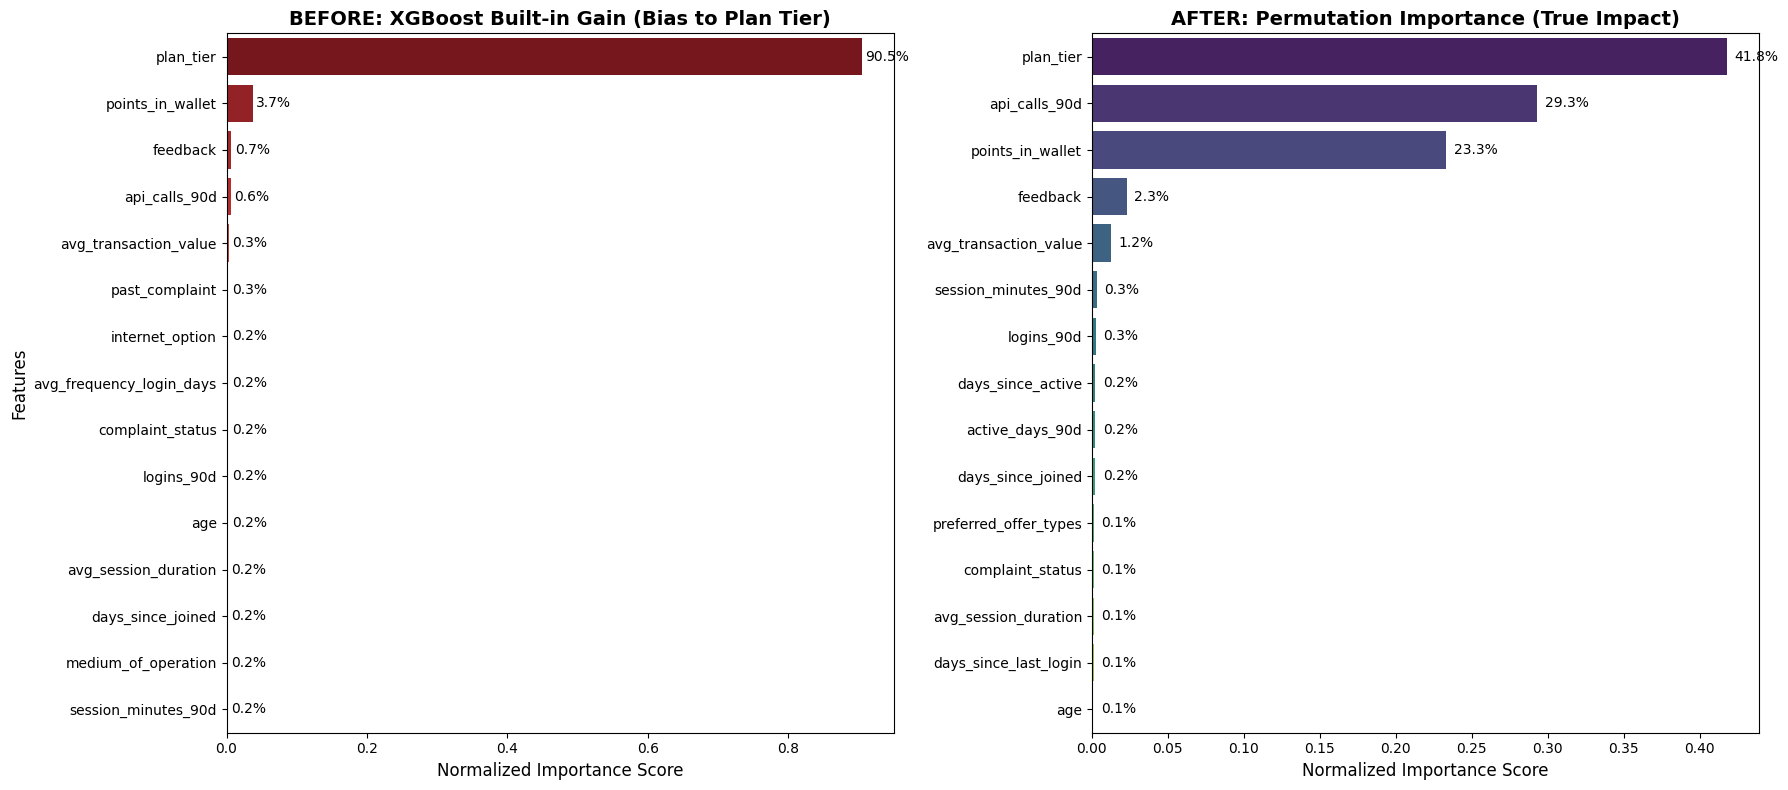

In [24]:
from sklearn.inspection import permutation_importance
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Mengambil XGBoost Built-in Importance (Gain)
builtin_importances = xgb_model.feature_importances_
builtin_importances = builtin_importances / np.sum(builtin_importances) # Normalize to 100%
builtin_sorted_idx = builtin_importances.argsort()[::-1]

# 2. Menghitung Permutation Importance
print('Menghitung Permutation Importance (ini mungkin memakan waktu beberapa detik)...')
perm_res = permutation_importance(xgb_model, X_test_scaled, y_test, n_repeats=5, random_state=42)

perm_importances = perm_res.importances_mean
perm_importances = np.maximum(perm_importances, 0)
if np.sum(perm_importances) > 0:
    perm_importances = perm_importances / np.sum(perm_importances)
perm_sorted_idx = perm_importances.argsort()[::-1]

# 3. Visualisasi Komparasi Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Grafik 1: Built-in Gain (Before)
sns.barplot(x=builtin_importances[builtin_sorted_idx][:15], 
            y=np.array(feature_names)[builtin_sorted_idx][:15], 
            palette='Reds_r', ax=axes[0])
axes[0].set_title('BEFORE: XGBoost Built-in Gain (Bias to Plan Tier)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Normalized Importance Score', fontsize=12)
axes[0].set_ylabel('Features', fontsize=12)
for i, v in enumerate(builtin_importances[builtin_sorted_idx][:15]):
    axes[0].text(v + 0.005, i, f'{v*100:.1f}%', va='center', fontsize=10)

# Grafik 2: Permutation Importance (After)
sns.barplot(x=perm_importances[perm_sorted_idx][:15], 
            y=np.array(feature_names)[perm_sorted_idx][:15], 
            palette='viridis', ax=axes[1])
axes[1].set_title('AFTER: Permutation Importance (True Impact)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Normalized Importance Score', fontsize=12)
axes[1].set_ylabel('') # Hilangkan ylabel agar rapi
for i, v in enumerate(perm_importances[perm_sorted_idx][:15]):
    axes[1].text(v + 0.005, i, f'{v*100:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()